In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel
import culRIBayesian.stan_utils as culRIB

import culRIBayesian
print(culRIBayesian.__version__)  

import culRIBayesian.dataviz_utils as dv
import importlib

import bayspline as bsl
import bayspar as bsr



0.1.0


In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)

def generalized_logistic_model(x, x0, A, K, B, v, Q, C=1):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - A: Lower asymptote (left asymptote)
    - K: the right horizontal asymptote when C = 1. If A = 0 and C = 1, then K is the carrying capacity.
    - B: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = A + ((K - A) / np.power(C + Q * np.exp(-B * (x - x0)), 1/v)
)
    return Y

def generalized_logistic_model_fixed_upper(x, x0, A, B, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - A: Lower asymptote (left asymptote)
    - B: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = A + ((1 - A) / np.power(1 + Q * np.exp(-B * (x - x0)), 1/v)
)
    return Y


In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# set the path to local folder other than github
login_name = os.getlogin()

from cmdstanpy import set_cmdstan_path
set_cmdstan_path(f"/home/{login_name}/.cmdstan/cmdstan-2.36.0")

from cmdstanpy import cmdstan_path
print(cmdstan_path())

### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

/home/ronnie-rattan/.cmdstan/cmdstan-2.36.0


# ensure fresh stan models

In [8]:
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"
os.environ["TBB_CXX_TYPE"] = "gcc"
os.environ["CMDSTAN"] = os.path.expanduser("~/.cmdstan/cmdstan-2.36.0")
from culRIBayesian.stan_utils import refresh_stan_models
refresh_stan_models(stan_models_dir=stan_models_path,n_jobs=8, clean=True)

08:09:17 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso


🔧 (Re)compiling 12 Stan model(s) via CmdStanPy…


08:09:23 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso
08:09:23 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
08:09:23 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso
08:09:29 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso
08:09:29 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/s

✅ Compiled: gen_logi_culmeso.stan


08:09:35 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore
08:09:35 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
08:09:35 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore
08:09:41 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore
08:09:41 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_hier_crtp_univ_priorApprox.stan to exe file /home/ronnie-rattan/Documents/GitHub

...

✅ Compiled: jnt_cul_meso_crtp.stan


08:11:12 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
08:11:12 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
08:11:12 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
08:11:17 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
08:11:17 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitH

✅ Compiled: jnt_cul_meso_hier_crtp.stan


08:11:23 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
08:11:23 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
08:11:23 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
08:11:29 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv


✅ Compiled: jnt_cul_meso_hier_crtp_multiv.stan
🚀 Done compiling Stan models.


In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0
  * time     (time) float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

# Raw coretop

In [11]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['deltaRI_flip'] = raw_coretop_df['ringIndex'] - raw_coretop_df['TEX_RI']

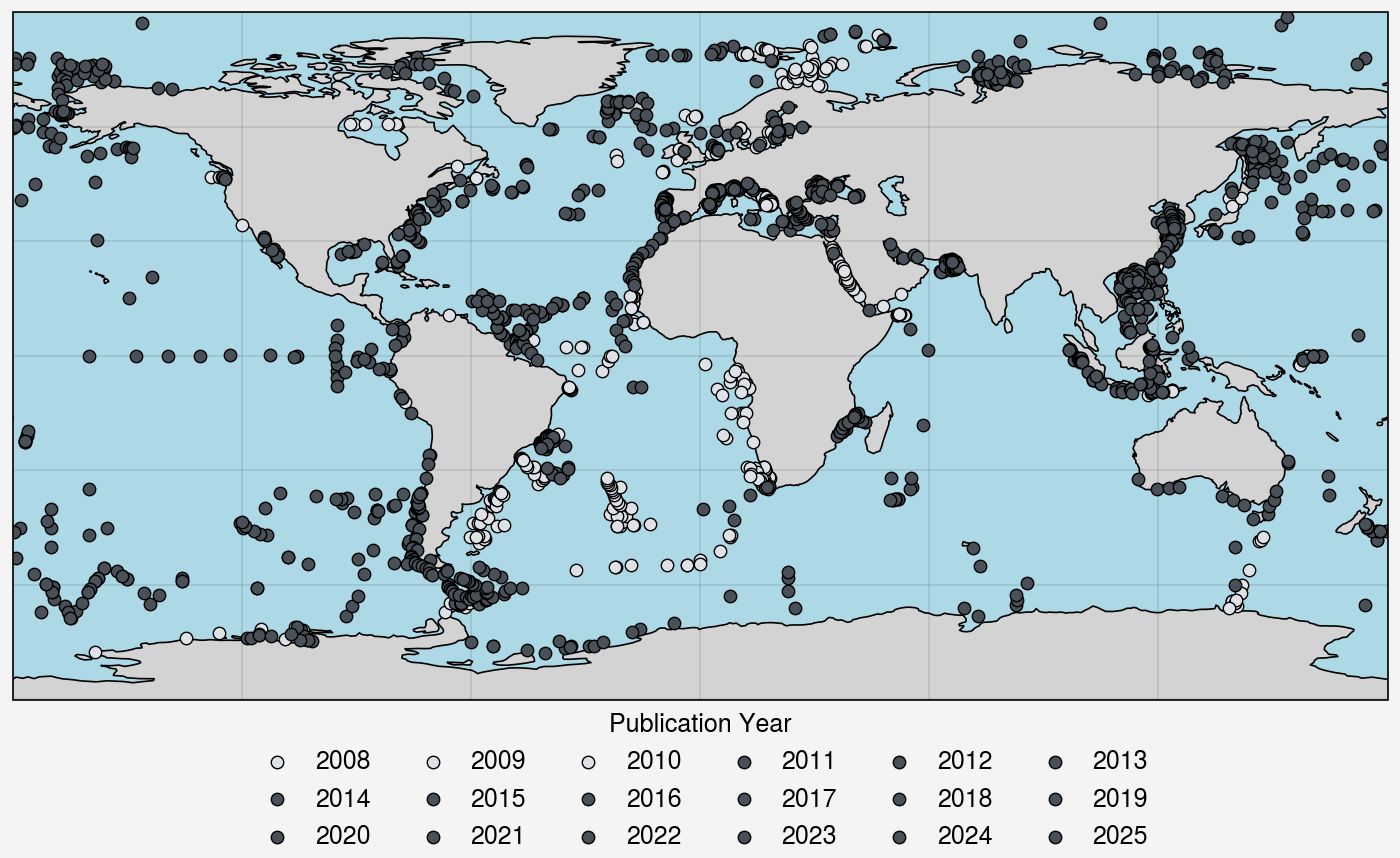

In [12]:
fig, axs = plot.subplots(proj='cyl', width=7)
axs.format(
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue'
)


grouped = raw_coretop_df.groupby('publicationYear')
for name, group in grouped:
    axs.scatter(group['Longitude'], group['Latitude'], label=int(name), s=20, zorder=2,
                mec='black', mew=0.5,
                c='gray7' if name > 2010 else 'gray3',)
    
axs.legend(loc='b', ncols=6, fontsize=8, frame=False, title='Publication Year')

Linear regression equation: $RI = 3.1517 * TEX86 + 0.5808$
Exponential regression equation: $ln(RI) = 1.4352 * TEX86 + 0.0244$


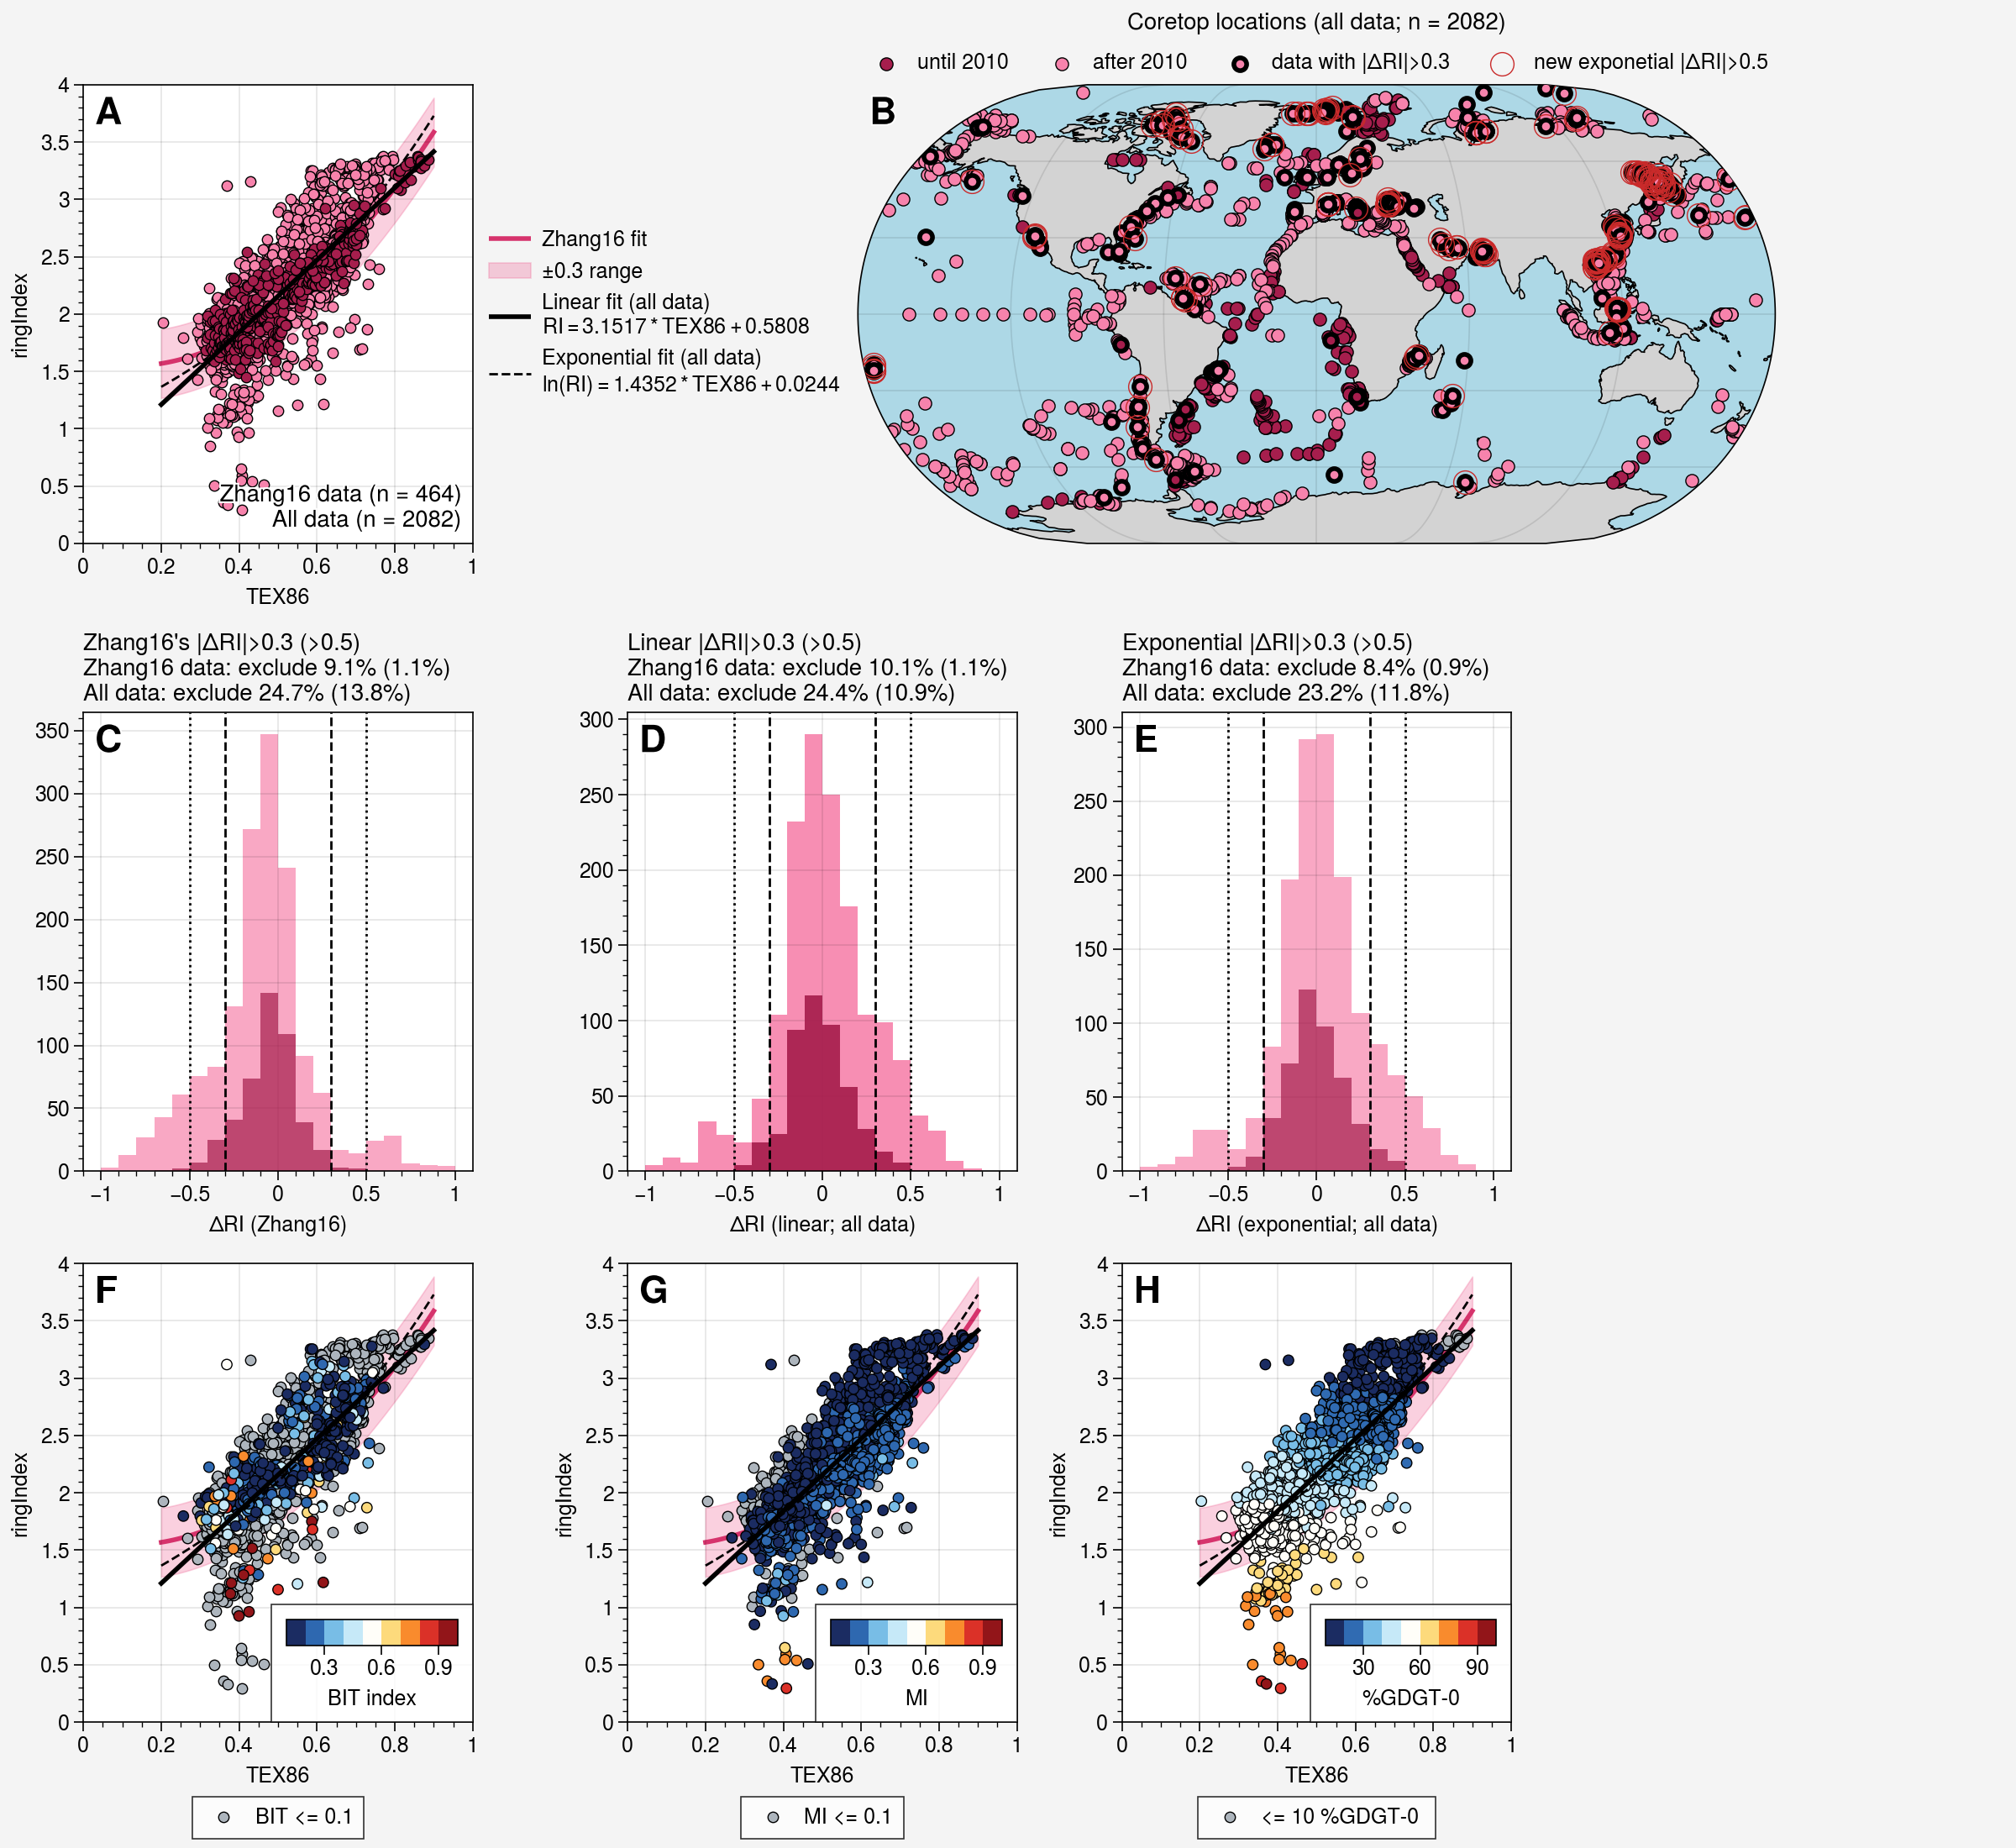

In [13]:
array = [
    [1,2,2,2],
    [3,4,5,0],
    [6,7,8,0],
]
fig, axs = plot.subplots(array,proj=(None,'eck3',None),
                         figsize=(12,11),share=0,
                         wspace=5,
                         hratios=(1,1,1),)

ax = axs[1]
ax.format(
    title=f'Coretop locations (all data; n = {len(raw_coretop_df)})',
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue',
)



grouped = raw_coretop_df.groupby('publicationYear')
for pubYear, group in grouped:

    ax = axs[0]
    ax.scatter(group['TEX86'], group['ringIndex'], label=int(pubYear), 
               s=20, mec='black', mew=0.5,
               c='pink4' if pubYear > 2010 else 'pink9',
               zorder= 2 if pubYear > 2010 else 3,)
    
    ax = axs[1]
    grouped2 = group.groupby('deltaRI_group')
    for deltaRI_group, group2 in grouped2:
        ax.scatter(group2['Longitude'], group2['Latitude'], label=int(pubYear), 
                s=30, 
                mec = 'black', 
                mew = 0.5 if deltaRI_group == '-0.3 to 0.3' else 2,
                zorder = 2 if deltaRI_group == '-0.3 to 0.3' else 3,
                c = 'pink4' if pubYear > 2010 else 'pink9',)


xx = np.linspace(0.2, 0.9, 100)
pred_texRI = -0.77*xx + 3.32*xx**2 + 1.59

pred_texRI_plus03 = pred_texRI + 0.3
pred_texRI_minus03 = pred_texRI - 0.3


### linear fit for all data
lin_reg = LinearRegression()
reg_data = raw_coretop_df.dropna(subset=['TEX86', 'ringIndex']).reset_index(drop=True)
X = reg_data['TEX86'].values.reshape(-1, 1)
y = reg_data['ringIndex'].values
lin_reg.fit(X, y)
slope = lin_reg.coef_[0]
yintercept = lin_reg.intercept_
equation_text = f'$RI = {slope:.4f} * TEX86 + {yintercept:.4f}$'
print(f'Linear regression equation: {equation_text}')

### exponential fit for all data
ln_y = np.log(y)
exp_reg = LinearRegression()
exp_reg.fit(X, ln_y)
exp_slope = exp_reg.coef_[0]
exp_yintercept = exp_reg.intercept_
exp_equation_text = f'$ln(RI) = {exp_slope:.4f} * TEX86 + {exp_yintercept:.4f}$'
print(f'Exponential regression equation: {exp_equation_text}')

sigma = np.std(y - lin_reg.predict(X))
pred_texRI_all = lin_reg.predict(xx.reshape(-1, 1))
pred_ln_texRI_all = np.exp(exp_reg.predict(xx.reshape(-1, 1)))
axs_idx = [0,5,6,7]
for idx in axs_idx:
    axs[idx].plot(xx, pred_texRI, color='pink7', lw=2, label='Zhang16 fit',zorder=1)
    axs[idx].fill_between(xx, pred_texRI_plus03, pred_texRI_minus03,
                   color='pink5', alpha=0.3, label='±0.3 range',
                   zorder=0)
    
    axs[idx].plot(xx, pred_texRI_all, 
                color='k', 
                zorder=3,
                lw=2, label='Linear fit (all data)\n'+equation_text)
    
    axs[idx].plot(xx, pred_ln_texRI_all,
                color='k', 
                ls='--', lw=1, label='Exponential fit (all data)\n'+exp_equation_text,
                zorder=2)
    
    axs[idx].format(
    xlim=(0,1),
    ylim=(0, 4),
    )

raw_coretop_df['pred_new_texRI'] = lin_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1))
raw_coretop_df['pred_new_ln_texRI'] = np.exp(exp_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1)))

raw_coretop_df['new_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df['new_ln_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_ln_texRI']

coretop_until2010 = raw_coretop_df[raw_coretop_df['publicationYear']<=2010].reset_index(drop=True)
coretop_after2010 = raw_coretop_df[raw_coretop_df['publicationYear']>2010].reset_index(drop=True)
axs[0].format(
    lrtitle=f'Zhang16 data (n = {len(coretop_until2010)})\nAll data (n = {len(raw_coretop_df)})',
)

ax = axs[2]
data1 = coretop_until2010['deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (Zhang16)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(f"Zhang16's |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (linear; all data)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(f"Linear |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_linear)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_linear)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_linear)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_linear)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[4]
data1 = coretop_until2010['new_ln_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_ln_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (exponential; all data)',
)
#### calculate how much data outside of ±0.3
inside_abs03_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(f"Exponential |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_ln)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_ln)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_ln)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_ln)/len(raw_coretop_df)*100):.1f}%)'),)


ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (linear; all data)',
)



plot_data = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])>0.5].reset_index(drop=True)
axs[1].scatter(
    plot_data['Longitude'], plot_data['Latitude'],
    zorder=4,
    s=100, mec='red9', mew=0.5, facecolor='none',
)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(
    [h[i] for i in [1,10,9,-1]], 
    ['until 2010', 'after 2010', 'data with |ΔRI|>0.3','new exponetial |ΔRI|>0.5'],
    # h,l,
    loc='t', ncols=4, frame=False,
)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(
    [h[i] for i in [0,-1,1,2]],
    [l[i] for i in [0,-1,1,2]],
    # h,l,
    loc='r', ncols=1, frame=False,
)

ax = axs[5]
plot_x = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['BIT']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='BIT <= 0.1')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['BIT']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['BIT']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['BIT']>0.1]['BIT']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,

           c=plot_c, cmap='coldhot',
           levels=np.arange(0.1, 1.1, 0.1),
           label='BIT index')
ax.colorbar(m, loc='lr', label='BIT index', ticks=np.arange(0.1, 1.1, 0.1))

ax = axs[6]
plot_x = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['methaneIndex']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='MI <= 0.1')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['methaneIndex']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='coldhot',
           levels=np.arange(0.1, 1.1, 0.1),
           label='MI')
ax.colorbar(m, loc='lr', label='MI', ticks=np.arange(0.1, 1.1, 0.1))

ax = axs[7]
plot_x = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['gdgtZeroOverZeroCren']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='<= 10 %GDGT-0 ')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['gdgtZeroOverZeroCren']*100
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='coldhot',
           levels=np.arange(10, 101, 10),
           label='%GDGT-0')
ax.colorbar(m, loc='lr', label='%GDGT-0', ticks=np.arange(10, 101, 10))

axs.format(
    abc=True,abcstyle='A',abcloc='ul',
    abcsize=16,abcweight='bold',
)

In [14]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# Define features
features = ['SST', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2',
            'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',]

# Replace inf/-inf with NaN, then drop rows with any NaN in selected features
X_clean = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna()
X_array = X_clean.to_numpy(dtype=float)

# Compute mean and covariance matrix
mean_vec = np.mean(X_array, axis=0)
cov_matrix = np.cov(X_array, rowvar=False)
inv_cov_matrix = inv(cov_matrix)

# Calculate Mahalanobis distance
distances = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_array]

# Create mask of valid (non-NaN/inf) rows to assign distances back to original df
valid_idx = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna().index

# Assign distances
raw_coretop_df['mahalanobis_distance'] = np.nan
raw_coretop_df.loc[valid_idx, 'mahalanobis_distance'] = distances
raw_coretop_df['mahalanobis_distance_weights'] = (
    1-((raw_coretop_df['mahalanobis_distance'] - raw_coretop_df['mahalanobis_distance'].min())
    / (raw_coretop_df['mahalanobis_distance'].max() - raw_coretop_df['mahalanobis_distance'].min()))
)   


In [15]:
from scipy.stats import chi2

dof = len(features)  # = 7
confidence = 0.99
threshold = chi2.ppf(confidence, df=dof)
# Square the Mahalanobis distances
squared_distances = np.square(distances)

# Identify which ones exceed the threshold
outlier_flags = squared_distances > threshold
# Assign NaN first
raw_coretop_df['mahalanobis_outlier'] = np.nan

# Assign True/False to valid rows only
raw_coretop_df.loc[valid_idx, 'mahalanobis_outlier'] = outlier_flags


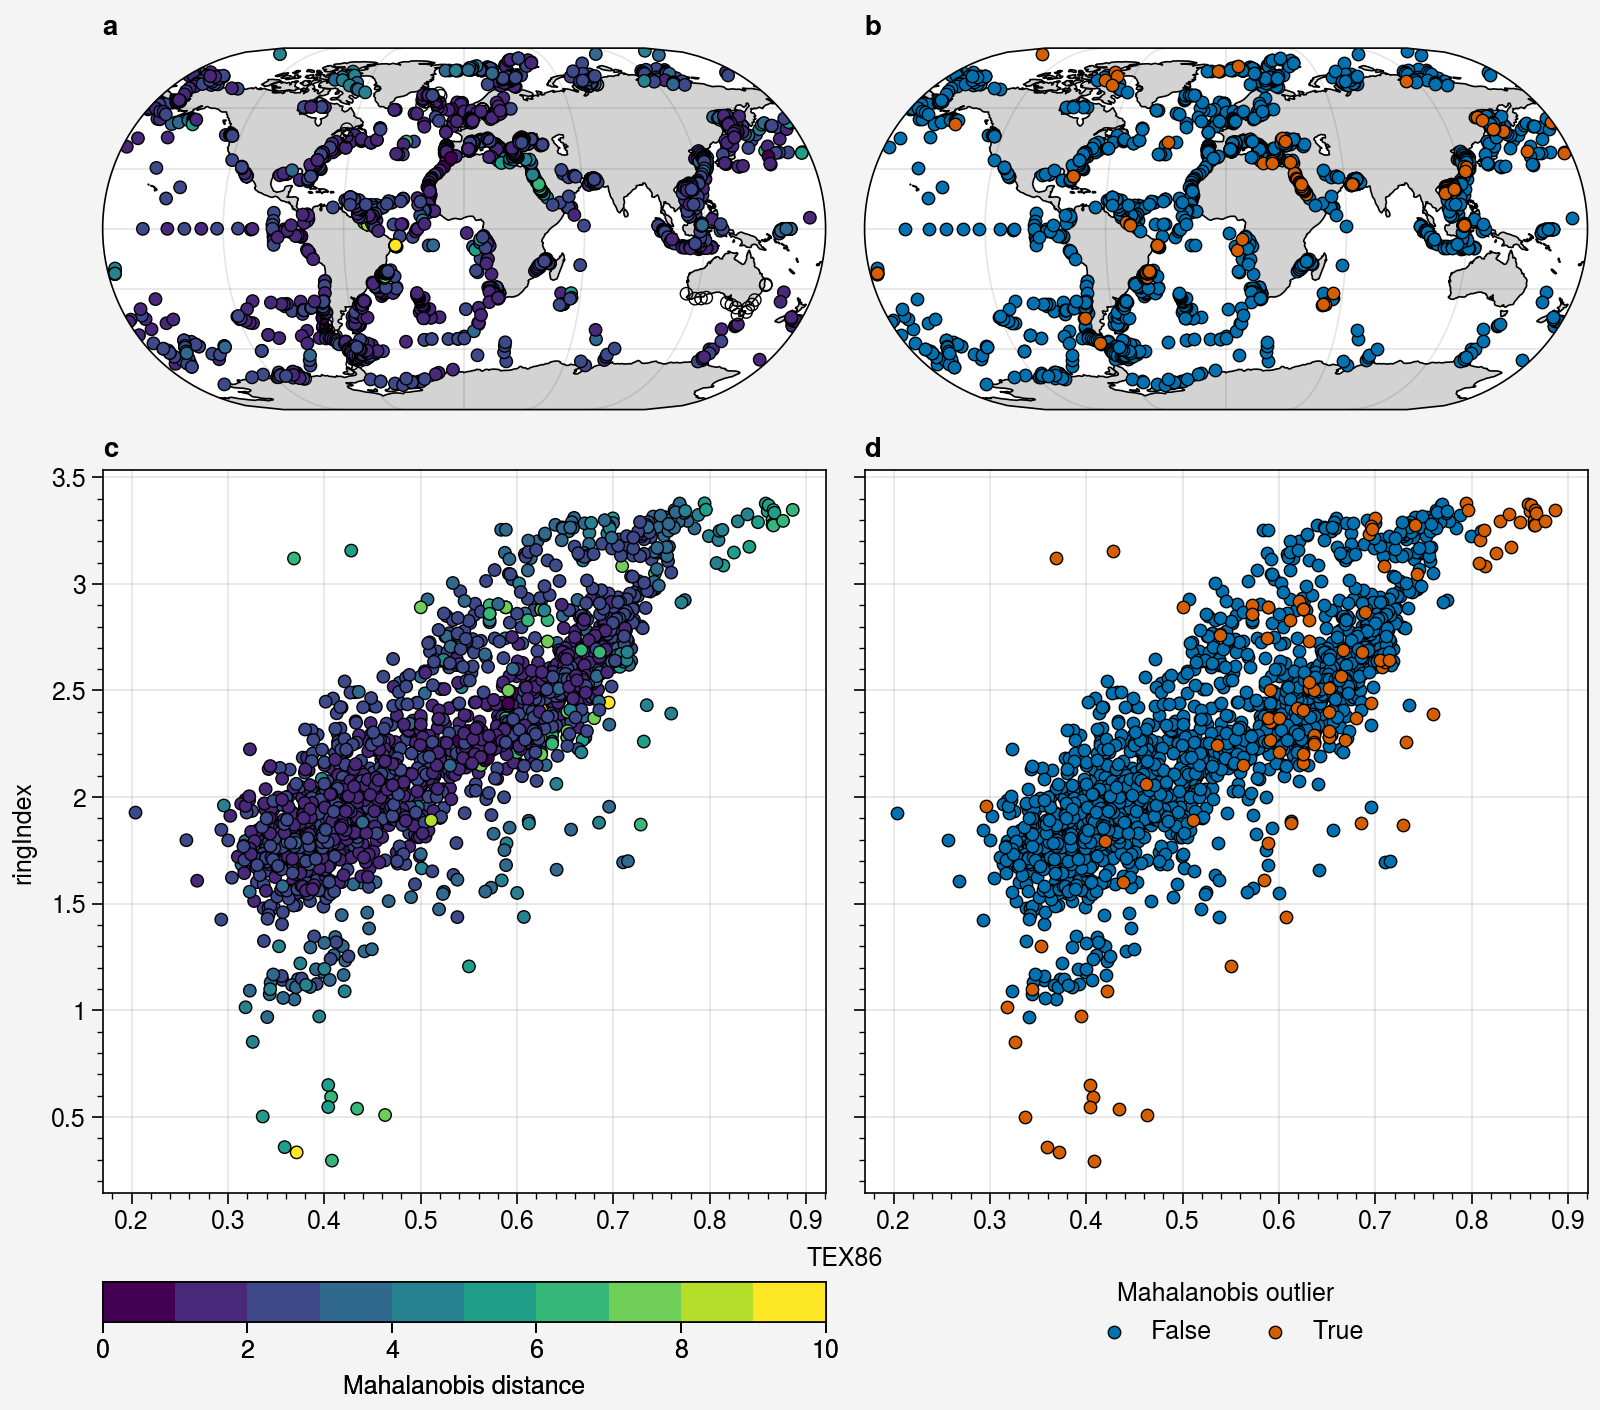

In [16]:
fig, axs = plot.subplots(width=8,ncols=2,nrows=2,
                         proj=('eck3','eck3',None),
                         hratios=[0.5,1])
ax = axs[0]
axs[0,:].format(
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
)
plot_lat = raw_coretop_df['Latitude']
plot_lon = raw_coretop_df['Longitude']
plot_c = raw_coretop_df['mahalanobis_distance']
m = ax.scatter(plot_lon, plot_lat, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 11, 1),
           label='Mahalanobis distance')

ax = axs[2]
plot_x = raw_coretop_df['TEX86']
plot_y = raw_coretop_df['ringIndex']
plot_c = raw_coretop_df['mahalanobis_distance']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 11, 1),
           label='Mahalanobis distance')
ax.colorbar(m, loc='b', label='Mahalanobis distance', 
            ticks=np.arange(0, 11, 1))

######################

grouped = raw_coretop_df.groupby('mahalanobis_outlier')
for name, group in grouped:
    axs[1].scatter(group['Longitude'], group['Latitude'], label=name,
                   s=20, zorder=2,
                   mec='black', mew=0.5)

    axs[3].scatter(group['TEX86'], group['ringIndex'], label=name,
               s=20, zorder=2,
               mec='black', mew=0.5)
    
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(h, l, loc='b', ncols=2, frame=False, title='Mahalanobis outlier')

# Gridded coretop

In [17]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname), engine='h5netcdf')
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 0.0
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [18]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

In [19]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])

coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI_fn(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951,1.750199,0.036001
1351,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041,1.654927,0.181673
1352,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180,1.921330,-0.321930
1353,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371,2.100132,-0.367832


In [20]:
# # ─── prepare sample points ────────────────────────────────────────────────────
# xx = np.linspace(-4, 50, 200)

# # ─── filter & group your data ──────────────────────────────────────────────────
# plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
# min_count = 2
# groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# # ─── build the figure with one trace per strain per model ─────────────────────
# fig = go.Figure()

# fig.add_trace(go.Scatter(
#     x=coretop_df['t_sf2tc_avg'],
#     y=coretop_df['scaledRI_median'],
#     mode='markers',
#     marker=dict(color='rgba(178,178,178,1.000)', size=5),
#     name='Core-top data',
#     showlegend=True   # you can allow toggling it via legend if you like
# ))
# core_idx = 0  # index of this core-top trace

# # ─── add global fits ────────────────────────────────────────────────
# X_all = plot_data['Temperature'].values.reshape(-1,1)
# y_all = plot_data['scaledRI'].values

# # -- Linear fit --
# ols_all = LinearRegression().fit(X_all, y_all)
# y_lin_all = ols_all.predict(xx.reshape(-1,1))


# # -- Logistic fixed upper --
# p0f = [25, 0.1, 0.1]
# bf = (0, [50,1,1])
# popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
# y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
# r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# # -- Full logistic --
# p0_all = [25,0.1,0.1,0.1]
# bnd_all = (0, [50,1,1,1])
# popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
# y_logi_all = logistic(xx, *popt_all)
# r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
#     ("Logistic fixed", y_logif_all, r2_logif_all),
#     ("Logistic", y_logi_all, r2_logi_all)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
#         visible=True
#     ))

# ### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
# X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
# y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# # -- Linear fit --
# ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
# y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# # -- Logistic fixed upper --
# p0f_full = [25, 0.1, 0.1]
# bf_full = (0, [50,1,1])
# popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
# y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
# r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# # -- Full logistic --
# p0_all_full = [25,0.1,0.1,0.1]
# bnd_all_full = (0, [50,1,1,1])
# popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
# y_logi_all_full = logistic(xx, *popt_all_full)
# r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
#     ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
#     ("Logistic", y_logi_all_full, r2_logi_all_full)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso_crtp -- {model} (R²={r2:.2f})",
#         visible=True
#     ))
    
# # ─── add all your strain traces ───────────────────────────
# for strain in groups:
#     df = plot_data[plot_data['Strains_edited'] == strain]
#     X = df['Temperature'].values.reshape(-1,1)
#     y = df['scaledRI'].values
    
#     # -- Linear fit --
#     ols = LinearRegression().fit(X, y)
#     y_lin = ols.predict(xx.reshape(-1,1))
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_lin, 
#         mode='lines',
#         name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
#         visible=(strain == groups[0])  # only first strain visible initially
#     ))
    
#     # -- Logistic fixed upper --
#     p0f = [25, 0.1, 0.1]
#     bf = (0, [50,1,1])
#     popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
#     y_logf = logistic_fixed_upper(xx, *popt_f)
#     r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_logf,
#         mode='lines',
#         name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
#         visible=False
#     ))
    
#     # -- Full logistic --
#     p0 = [25,0.1,0.1,0.1]
#     bnd = (0, [50,1,1,1])
#     popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
#     y_log = logistic(xx, *popt)
#     r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_log,
#         mode='lines',
#         name=f"{strain} -- Logistic (R²={r2:.2f})",
#         visible=False
#     ))
    
#     # -- Always-on scatter of raw data --
#     fig.add_trace(go.Scatter(
#         x=df['Temperature'], y=df['scaledRI'],
#         mode='markers',
#         marker=dict(size=6, line=dict(width=1, color='black')),
#         name=f"{strain} -- data",
#         visible=True
#     ))
# # build a mapping strain → color
# palette1 = px.colors.qualitative.Set1
# palette2 = px.colors.qualitative.Set2

# # make one long list
# all_colors = palette1 + palette2

# # then map strains in order
# strain_colors = {
#     strain: all_colors[i % len(all_colors)]
#     for i, strain in enumerate(groups)
# }

# # now loop through all traces
# for trace in fig.data:
#     # The “cultures + mesocosm only” global fit
#     if trace.name.startswith("glob_cul_meso --"):
#         trace.update(line=dict(
#             color="black",   # pick any CSS name or hex code
#             dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
#             width=4              # thicker line
#         ))

#     # The “cultures + mesocosm + coretop” global fit
#     elif trace.name.startswith("glob_cul_meso_crtp --"):
#         trace.update(line=dict(
#             color="black",
#             dash="dashdot",
#             width=3
#         ))
        
#     # skip the core-top (and any other truly global or background traces)
#     elif trace.name == "Core-top data":
#         continue

#     # split off the strain name (everything before the “ – ”)
#     strain = trace.name.split(" -- ")[0]

#     # pick a color: if it’s one of our strains, use its palette color;
#     # otherwise (e.g. “Global”) fall back to black or whatever you like
#     col = strain_colors.get(strain, "black")

#     # apply to both marker & line
#     trace.update(
#         marker=dict(color=col),
#         line=dict(color=col)
#     )



# # Hide all line traces (fits) by default, leave markers visible
# for trace in fig.data:
#     if "lines" in trace.mode:
#         trace.visible = "legendonly"
#     else:
#         trace.visible = True

# # # Make “raw data” the initial visibility state:
# # for tr in fig.data:
# #     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
# #         tr.visible = True
# #     else:
# #         tr.visible = False
        


# # reposition the model‐dropdown as a vertical nav bar on the left
# fig.update_layout(

#     autosize=False,     # turn off responsive “fill the container”
#     width=900,          # fixed pixel width
#     height=500,         # fixed pixel height
#     margin=dict(l=40, r=40, t=50, b=40),

#     title="Scaled RI vs Temperature",
#     xaxis_title="Temperature (°C)",
#     yaxis_title="Scaled RI",
    
#     yaxis=dict(
#         range=[0.1, 1.1],
#         autorange=False    # turn off auto‐scaling
#     ),

#     # put the legend also on the left, so users can click each strain on/off
#     legend=dict(
#         traceorder="normal",
#         orientation="v",
#         x=1.13,      # just inside the left margin
#         y=0.5,
#         xanchor="left",
#         yanchor="middle",
#         itemsizing="constant"
#     ),
#     template='seaborn',
#     font=dict(
#         family="TeX Gyre Heros",
#         size=14,
#         color="black"
#     ),
    
# )

# # lock X/Y so the units match (remove if you don’t want a 1:1 scale)
# fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# # set a default
# # fig.update_layout(template="plotly_white")

# fig.show()

# # in your Python script / notebook:
# fig.write_html(
#   os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
#   include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#   full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )


In [21]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df


,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951,1.750199,0.036001
1350,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041,1.654927,0.181673
1351,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180,1.921330,-0.321930
1352,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371,2.100132,-0.367832


# PhanSST on TEX-RI relationship

In [22]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

In [23]:
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['pred_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='zhang16')
PhanTEX_df['deltaRI'] = PhanTEX_df['pred_texRI'] - PhanTEX_df['ringIndex']
PhanTEX_df['deltaRI_flip'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_texRI']
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
PhanTEX_df['pred_new_linear_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='linear_thisStudy')
PhanTEX_df['pred_new_exp_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='exp_thisStudy')
PhanTEX_df['new_linear_deltaRI'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_new_linear_texRI']
PhanTEX_df['new_exp_deltaRI'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_new_exp_texRI']

In [24]:
PhanTEX_df['hothouse_flag'] = [
    1 if PhanTEX_df['Period'][i] in ['Cretaceous'] 
    or PhanTEX_df['Stage'][i] in ['Lutetian', 'Ypresian'] 
    else 0 for i in range(len(PhanTEX_df))
]
PhanTEX_df['hothouse_flag'].unique()

array([1, 0])

Linear regression equation: $RI = 3.1398 * TEX86 + 0.5876$
Weighted linear regression equation: $RI = 3.1008 * TEX86 + 0.6111$
Linear regression equation (mahalanobis < 4): $RI = 3.0884 * TEX86 + 0.6256$
Exponential regression equation: $ln(RI) = 1.4312 * TEX86 + 0.0269$
Weighted exponential regression equation: $ln(RI) = 1.4053 * TEX86 + 0.0445$
Exponential regression equation (mahalanobis < 4): $ln(RI) = 1.3878 * TEX86 + 0.0601$
Log10 regression equation: $log10(RI) = 0.6215 * TEX86 + 0.0117$
Polynomial regression equation: $RI = -11.5641 * TEX86^3 + 0.0000 * TEX86^2 + 2.7901$


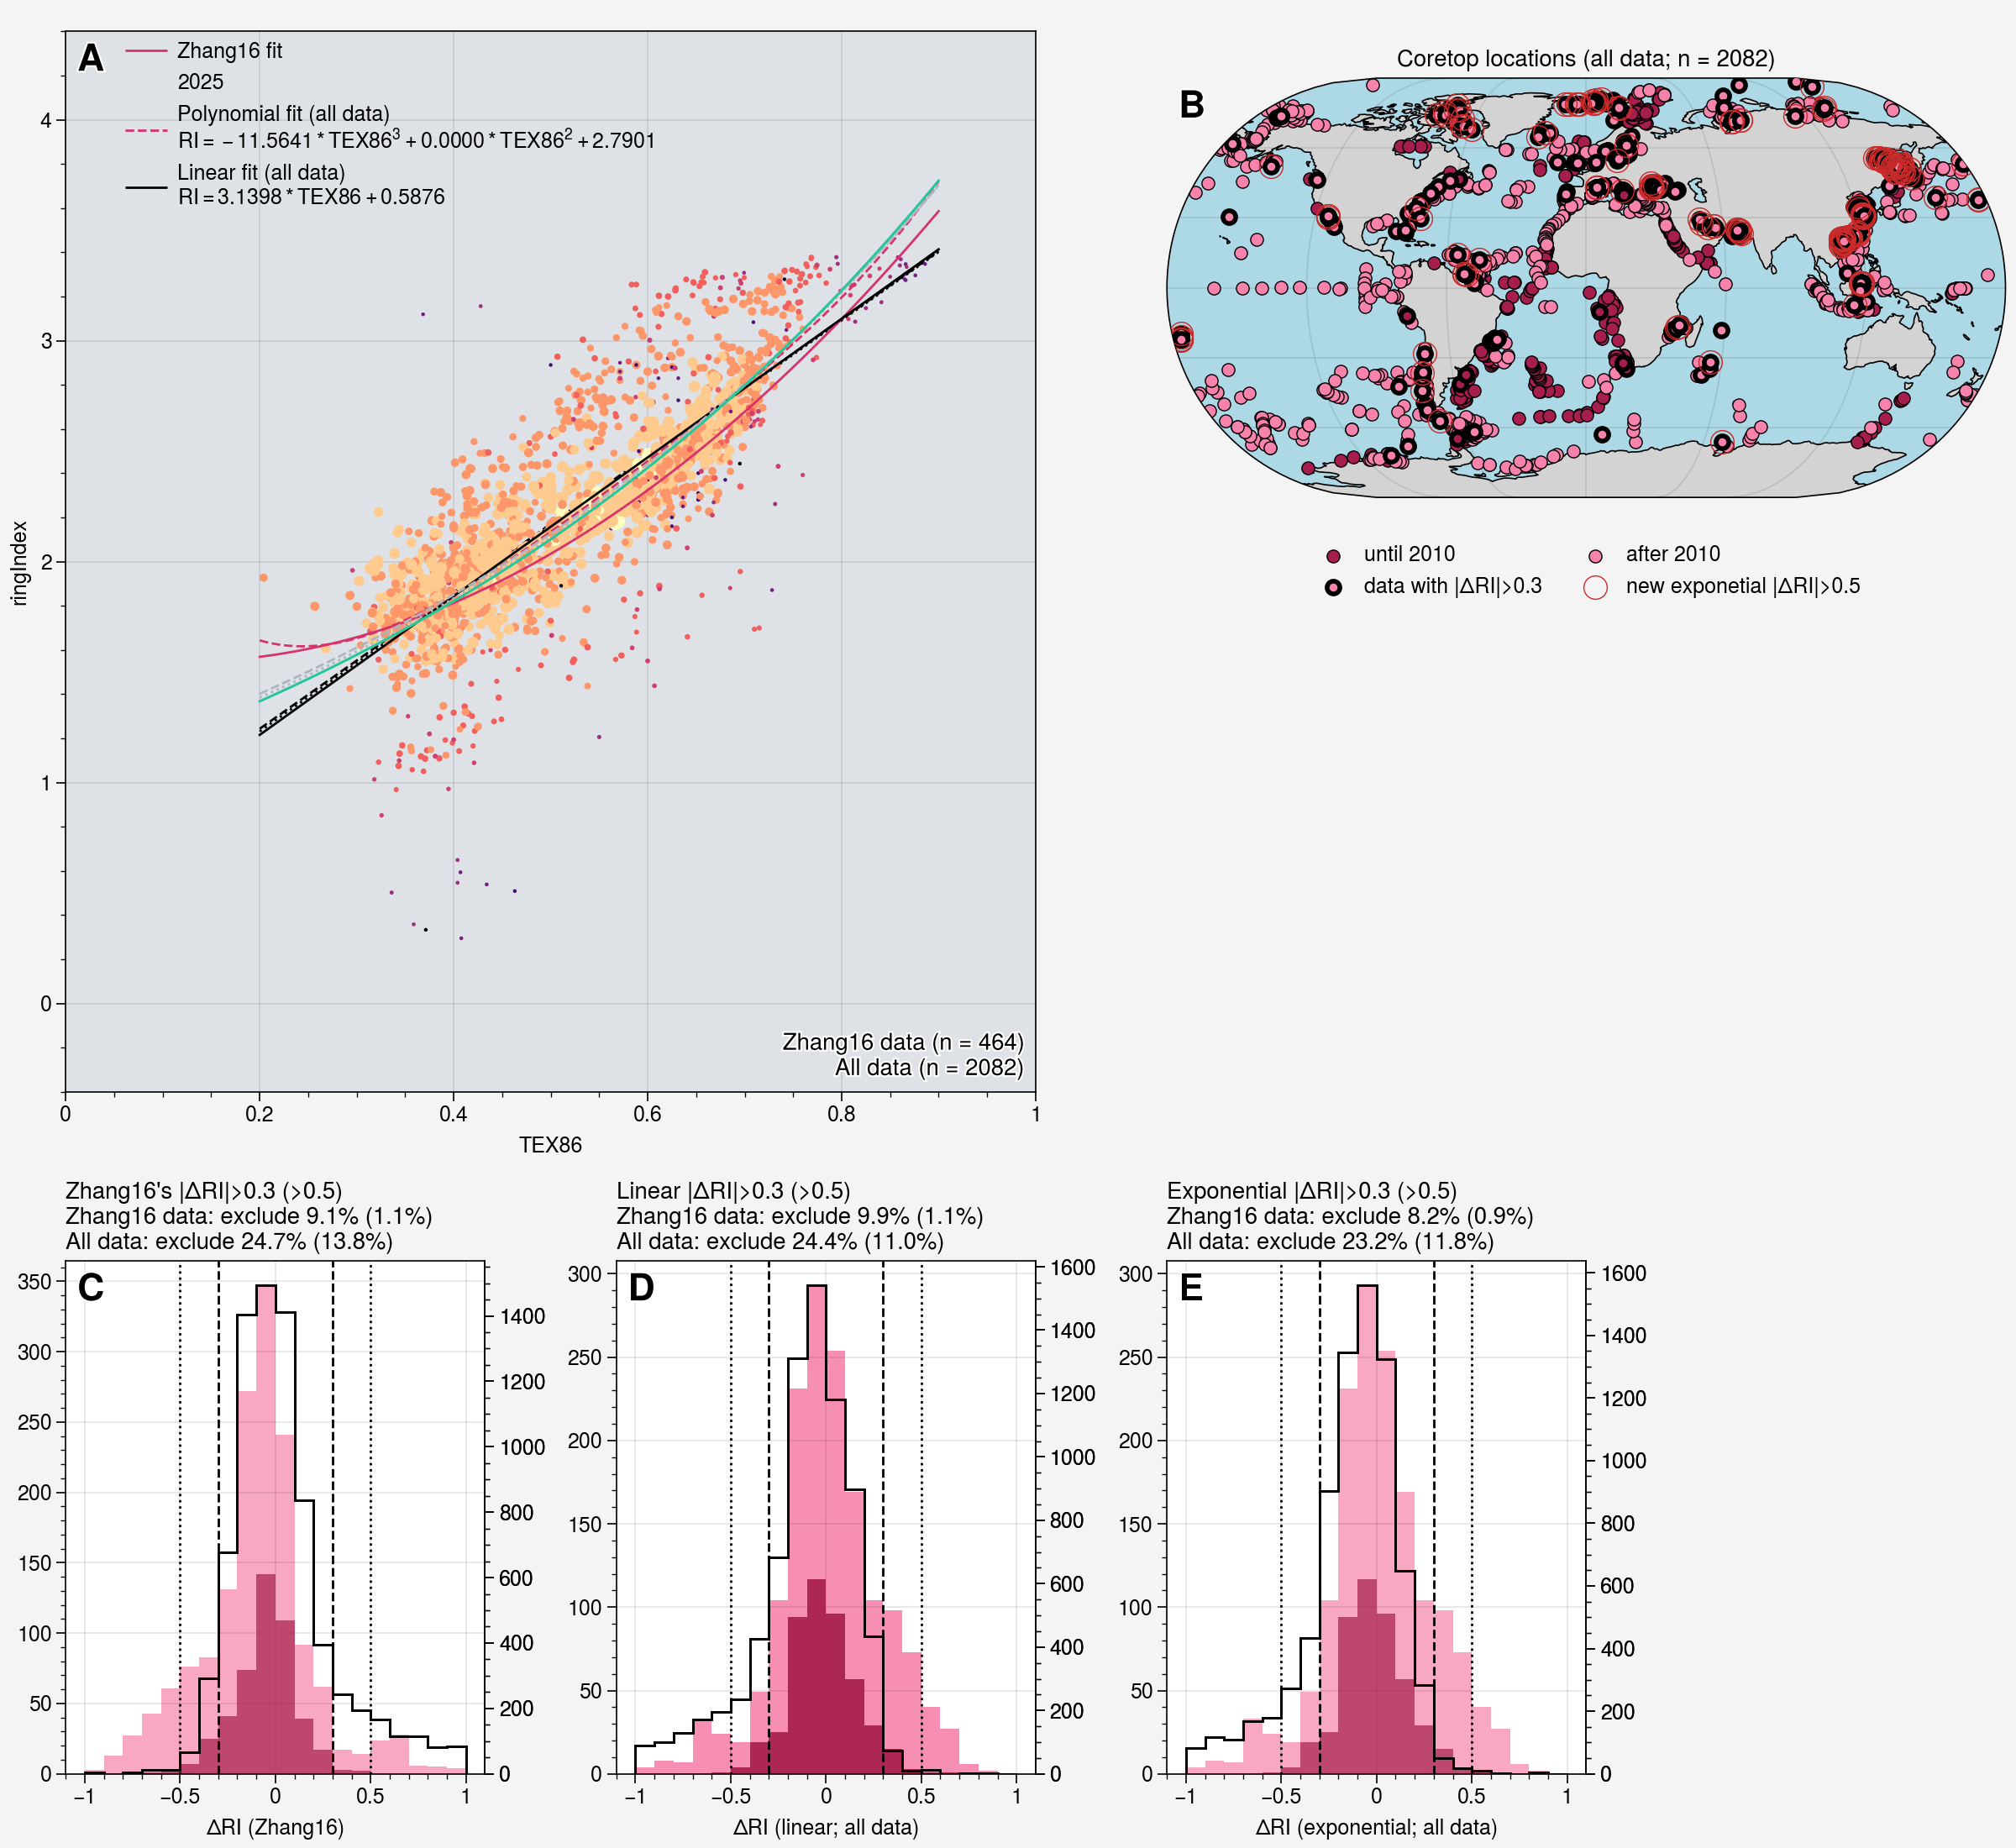

In [25]:
array = [
    [1,1,2,2],
    [1,1,0,0],
    [3,4,5,0]
]
fig, axs = plot.subplots(array,proj=(None,'eck3',None),
                         figsize=(12,11),
                         share=0,
                        #  wspace=8,
                         hratios=(1,1,1),)

ax = axs[1]
ax.format(
    title=f'Coretop locations (all data; n = {len(raw_coretop_df)})',
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue',
)
ax = axs[0]
plot_data = raw_coretop_df
ax.scatter(plot_data['TEX86'], plot_data['ringIndex'], label=int(pubYear), 
        # s=10,0
        s=plot_data['mahalanobis_distance_weights']**10, 
        # mec='k', 
        # mew=0.5,
        #    c='pink4' if pubYear > 2010 else 'pink9',
        c=plot_data['mahalanobis_distance'],levels=np.arange(0, 11, 1),
        cmap='magma_r',
        zorder=3)


grouped = raw_coretop_df.groupby('publicationYear')
for pubYear, group in grouped:

    # ax = axs[0]
    # ax.scatter(group['TEX86'], group['ringIndex'], label=int(pubYear), 
    #         s=10,
    #         #    s=((1/group['mahalanobis_distance'])*10)**2, 
    #         #    mec='black', mew=0.5,
    #         #    c='pink4' if pubYear > 2010 else 'pink9',
    #         c=group['mahalanobis_distance'],
    #         zorder= 2 if pubYear > 2010 else 3,)
    
    ax = axs[1]
    grouped2 = group.groupby('deltaRI_group')
    for deltaRI_group, group2 in grouped2:
        ax.scatter(group2['Longitude'], group2['Latitude'], label=int(pubYear), 
                s=30, 
                mec = 'black', 
                mew = 0.5 if deltaRI_group == '-0.3 to 0.3' else 2,
                zorder = 2 if deltaRI_group == '-0.3 to 0.3' else 3,
                c = 'pink4' if pubYear > 2010 else 'pink9',)

# ### plot PhanTEX data
# paleo_grouped = PhanTEX_df.groupby('hothouse_flag')
# hothouse_flag_dict = {0: 'non-hothouse', 1: 'hothouse'}
# for hothouse_flag, group in paleo_grouped: 
#     ax = axs[0]
#     ax.scatter(group['TEX86'], group['ringIndex'], label=hothouse_flag_dict.get(hothouse_flag), 
#                s=10, 
#             #    mec='black', mew=0.5,
#                c='blue9' if hothouse_flag == 1 else 'blue4',
#                zorder= 1 if hothouse_flag == 1 else 0)

xx = np.linspace(0.2, 0.9, 100)
pred_texRI = -0.77*xx + 3.32*xx**2 + 1.59
pred_texRI_plus03 = pred_texRI + 0.3
pred_texRI_minus03 = pred_texRI - 0.3


### linear fit for all data
lin_reg = LinearRegression()
min_tex_threshold = 0
reg_data = raw_coretop_df[raw_coretop_df['TEX86']>min_tex_threshold].dropna(subset=['TEX86', 'ringIndex','mahalanobis_distance_weights']).reset_index(drop=True)
X = reg_data['TEX86'].values.reshape(-1, 1)
y = reg_data['ringIndex'].values
lin_reg.fit(X, y)
slope = lin_reg.coef_[0]
yintercept = lin_reg.intercept_
equation_text = f'$RI = {slope:.4f} * TEX86 + {yintercept:.4f}$'
print(f'Linear regression equation: {equation_text}')

## weighted linear regression based on mahalanobis distance (higher distance = lower weight)
weights = reg_data['mahalanobis_distance_weights']
lin_reg_weighted = LinearRegression()
lin_reg_weighted.fit(X, y, sample_weight=weights)
slope_weighted = lin_reg_weighted.coef_[0]
yintercept_weighted = lin_reg_weighted.intercept_
equation_text_weighted = f'$RI = {slope_weighted:.4f} * TEX86 + {yintercept_weighted:.4f}$'
print(f'Weighted linear regression equation: {equation_text_weighted}')

### linear fit for only data with mahalanobis distance < 4
lin_reg_mahalanobis = LinearRegression()
reg_data_mahalanobis = reg_data[reg_data['mahalanobis_distance'] < 4].reset_index(drop=True)
X_mahalanobis = reg_data_mahalanobis['TEX86'].values.reshape(-1, 1)
y_mahalanobis = reg_data_mahalanobis['ringIndex'].values
lin_reg_mahalanobis.fit(X_mahalanobis, y_mahalanobis)
slope_mahalanobis = lin_reg_mahalanobis.coef_[0]
yintercept_mahalanobis = lin_reg_mahalanobis.intercept_
equation_text_mahalanobis = f'$RI = {slope_mahalanobis:.4f} * TEX86 + {yintercept_mahalanobis:.4f}$'
print(f'Linear regression equation (mahalanobis < 4): {equation_text_mahalanobis}')

### exponential fit for all data
ln_y = np.log(y)
exp_reg = LinearRegression()
exp_reg.fit(X, ln_y)
exp_slope = exp_reg.coef_[0]
exp_yintercept = exp_reg.intercept_
exp_equation_text = f'$ln(RI) = {exp_slope:.4f} * TEX86 + {exp_yintercept:.4f}$'
print(f'Exponential regression equation: {exp_equation_text}')

sigma = np.std(y - lin_reg.predict(X))
pred_texRI_all = lin_reg.predict(xx.reshape(-1, 1))
pred_ln_texRI_all = np.exp(exp_reg.predict(xx.reshape(-1, 1)))

### weighted exponential fit based on mahalanobis distance (higher distance = lower weight)
weights_exp = reg_data['mahalanobis_distance_weights']
exp_reg_weighted = LinearRegression()
exp_reg_weighted.fit(X, ln_y, sample_weight=weights_exp)
exp_slope_weighted = exp_reg_weighted.coef_[0]
exp_yintercept_weighted = exp_reg_weighted.intercept_
exp_equation_text_weighted = f'$ln(RI) = {exp_slope_weighted:.4f} * TEX86 + {exp_yintercept_weighted:.4f}$'
print(f'Weighted exponential regression equation: {exp_equation_text_weighted}')

### exp fit for only data with mahalanobis distance < 4
exp_reg_mahalanobis = LinearRegression()
reg_data_mahalanobis = reg_data[reg_data['mahalanobis_distance'] < 4].reset_index(drop=True)
X_mahalanobis = reg_data_mahalanobis['TEX86'].values.reshape(-1, 1)
y_mahalanobis = reg_data_mahalanobis['ringIndex'].values
exp_reg_mahalanobis.fit(X_mahalanobis, np.log(y_mahalanobis))
exp_slope_mahalanobis = exp_reg_mahalanobis.coef_[0]
exp_yintercept_mahalanobis = exp_reg_mahalanobis.intercept_
exp_equation_text_mahalanobis = f'$ln(RI) = {exp_slope_mahalanobis:.4f} * TEX86 + {exp_yintercept_mahalanobis:.4f}$'
print(f'Exponential regression equation (mahalanobis < 4): {exp_equation_text_mahalanobis}')

### np.log10 fit for all data
log10_y = np.log10(y)
log10_reg = LinearRegression()
log10_reg.fit(X, log10_y)
log10_slope = log10_reg.coef_[0]
log10_yintercept = log10_reg.intercept_
log10_equation_text = f'$log10(RI) = {log10_slope:.4f} * TEX86 + {log10_yintercept:.4f}$'
print(f'Log10 regression equation: {log10_equation_text}')

## weighted 3-degree polynomial fit based on mahalanobis distance (higher distance = lower weight)
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y, sample_weight=weights)
poly_slope = poly_reg.coef_[1]
poly_yintercept = poly_reg.intercept_
poly_equation_text = f'$RI = {poly_slope:.4f} * TEX86^3 + {poly_reg.coef_[0]:.4f} * TEX86^2 + {poly_yintercept:.4f}$'
print(f'Polynomial regression equation: {poly_equation_text}')
axs_idx = [0]
for idx in axs_idx:
    axs[idx].plot(xx, pred_texRI, color='pink7', lw=1, label='Zhang16 fit',zorder=4)
    # axs[idx].fill_between(xx, pred_texRI_plus03, pred_texRI_minus03,
    #                color='pink5', alpha=0.3, label='±0.3 range',
    #                zorder=0)
    
    axs[idx].plot(xx, poly_reg.predict(poly_features.transform(xx.reshape(-1, 1))),
                color='pink7', 
                ls='--', lw=1, label='Polynomial fit (all data)\n'+poly_equation_text,
                zorder=4)
    
    axs[idx].plot(xx, pred_texRI_all, 
                color='k', 
                zorder=5,
                lw=1, label='Linear fit (all data)\n'+equation_text)
    
    axs[idx].plot(xx, lin_reg_weighted.predict(xx.reshape(-1, 1)),
                color='k', 
                ls=':', lw=1, label='Weighted linear fit (all data)\n'+equation_text_weighted)
    
    
    axs[idx].plot(xx, lin_reg_mahalanobis.predict(xx.reshape(-1, 1)),
                color='k', 
                ls='--', lw=1, label='Linear fit (mahalanobis < 4)\n'+equation_text_mahalanobis)

    axs[idx].plot(xx, pred_ln_texRI_all,
                color='gray5', 
                lw=1, label='Exponential fit (all data)\n'+exp_equation_text,
                zorder=6)
    
    axs[idx].plot(xx, np.exp(exp_reg_weighted.predict(xx.reshape(-1, 1))),
                color='gray5', 
                ls=':', lw=1, label='Weighted exponential fit (all data)\n'+exp_equation_text_weighted,
                zorder=6)
    
    axs[idx].plot(xx, np.exp(exp_reg_mahalanobis.predict(xx.reshape(-1, 1))),
                color='gray5', 
                ls='--', lw=1, label='Exponential fit (mahalanobis < 4)\n'+exp_equation_text_mahalanobis,
                zorder=7)
    axs[idx].plot(xx, np.power(10, log10_reg.predict(xx.reshape(-1, 1))),
                color='teal5',
                lw=1, label='Log10 fit (all data)\n'+log10_equation_text,
                zorder=8)
    
    axs[idx].format(
    xlim=(0,1),
    ylim=(-0.4,4.4),
    )

raw_coretop_df['pred_new_texRI'] = lin_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1))
raw_coretop_df['pred_new_ln_texRI'] = np.exp(exp_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1)))

raw_coretop_df['new_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df['new_ln_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_ln_texRI']

coretop_until2010 = raw_coretop_df[raw_coretop_df['publicationYear']<=2010].reset_index(drop=True)
coretop_after2010 = raw_coretop_df[raw_coretop_df['publicationYear']>2010].reset_index(drop=True)
axs[0].format(
    lrtitle=f'Zhang16 data (n = {len(coretop_until2010)})\nAll data (n = {len(raw_coretop_df)})',
)

ax = axs[2]
data1 = coretop_until2010['deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)


ax.twinx().hist(PhanTEX_df['deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (Zhang16)',
        zorder=3)

ax.format(
    xlabel='ΔRI (Zhang16)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(f"Zhang16's |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.twinx().hist(PhanTEX_df['new_linear_deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (linear)',
        zorder=3)

ax.format(
    xlabel='ΔRI (linear; all data)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(f"Linear |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_linear)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_linear)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_linear)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_linear)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[4]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)

ax.twinx().hist(PhanTEX_df['new_exp_deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (exponential)',
        zorder=3)

ax.format(
    xlabel='ΔRI (exponential; all data)',
)
#### calculate how much data outside of ±0.3
inside_abs03_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(f"Exponential |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_ln)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_ln)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_ln)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_ln)/len(raw_coretop_df)*100):.1f}%)'),)


ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)

ax.format(
    xlabel='ΔRI (linear; all data)',
)



plot_data = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])>0.5].reset_index(drop=True)
axs[1].scatter(
    plot_data['Longitude'], plot_data['Latitude'],
    zorder=4,
    s=100, mec='red9', mew=0.5, facecolor='none',
)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(
    [h[i] for i in [1,10,9,-1]], 
    ['until 2010', 'after 2010', 'data with |ΔRI|>0.3','new exponetial |ΔRI|>0.5'],
    # h,l,
    loc='b', ncols=2, frame=False,
)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(
    [h[i] for i in [0,-1,1,2]],
    [l[i] for i in [0,-1,1,2]],
    # h,l,
    loc='ul', ncols=1, frame=False,
    bbox_to_anchor=(0.05, 1),
)

axs[0].format(facecolor='gray3')

axs.format(
    abc=True,abcstyle='A',abcloc='ul',
    abcsize=16,abcweight='bold',
)

In [26]:
raw_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'deltaRI_group', 'deltaRI_flip',
       'pred_new_texRI', 'pred_new_ln_texRI', 'new_deltaRI', 'new_ln_deltaRI'],
      dtype='object')

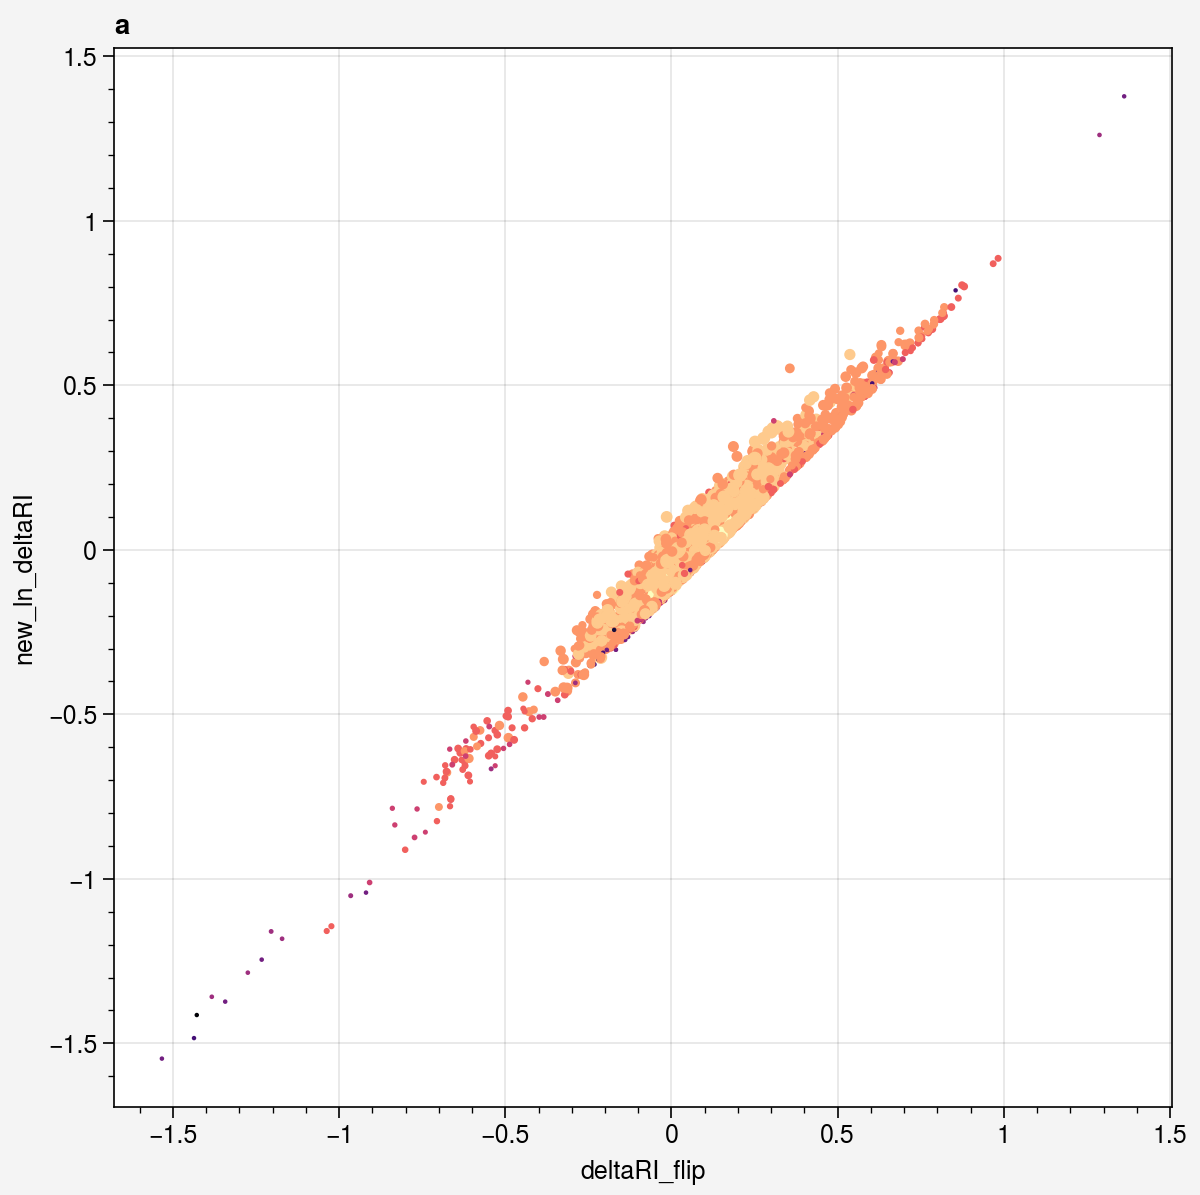

In [27]:
fig, axs = plot.subplots(width=6)

ax = axs[0]
plot_x = raw_coretop_df['deltaRI_flip']
plot_y = raw_coretop_df['new_ln_deltaRI']
ax.scatter(plot_x, plot_y, 
           s=raw_coretop_df['mahalanobis_distance_weights']**10,
           c=raw_coretop_df['mahalanobis_distance'], levels=np.arange(0, 11, 1),
           cmap='magma_r',
           zorder=3)

# Input Data for stan models

In [28]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()



In [29]:
## combined coretop and culture/mesocosm to a single dataframe
sel_cul_data = culture_data_full.reset_index(drop=True)

combined_df = pd.DataFrame({
    't_sf2tc': pd.concat([coretop_df['t_sf2tc_avg'], 
                          sel_cul_data['Temperature'], 
                          meso_data_full['Temperature']]),
    'scaledRI': pd.concat([coretop_df['scaledRI_median'], 
                           sel_cul_data['scaledRI'], 
                           meso_data_full['scaledRI']]),
    'gdgt23ratio': pd.concat([coretop_df['gdgt23ratio_median'], 
                              sel_cul_data['gdgt23ratio'], 
                              meso_data_full['gdgt23ratio']]),
    'datatype': pd.concat(
        [pd.Series(['coretop'] * len(coretop_df)),
         pd.Series(['culture'] * len(sel_cul_data)),
         pd.Series(['mesocosm'] * len(meso_data_full))]
    )
})

combined_df

,t_sf2tc,scaledRI,gdgt23ratio,datatype
0,-1.636017,0.509982,1.502839,coretop
1,-1.586854,0.438075,2.833333,coretop
2,-1.692642,0.410931,1.824832,coretop
3,-1.498910,0.433342,2.066396,coretop
4,-1.651191,0.447518,2.040640,coretop
...,...,...,...,...
16,25.000000,0.693123,2.629108,mesocosm
17,32.000000,0.656972,3.553719,mesocosm
18,34.000000,0.809038,2.318038,mesocosm
19,36.000000,0.899697,2.396907,mesocosm


# Simple curve-fitting comparison

Inflection point (logistic): 29.4439
Inflection point (logistic-fixed-upper): 28.4213
Inflection point (generalized logistic): 29.9551
Inflection point (generalized logistic-fixed-upper): 28.9326


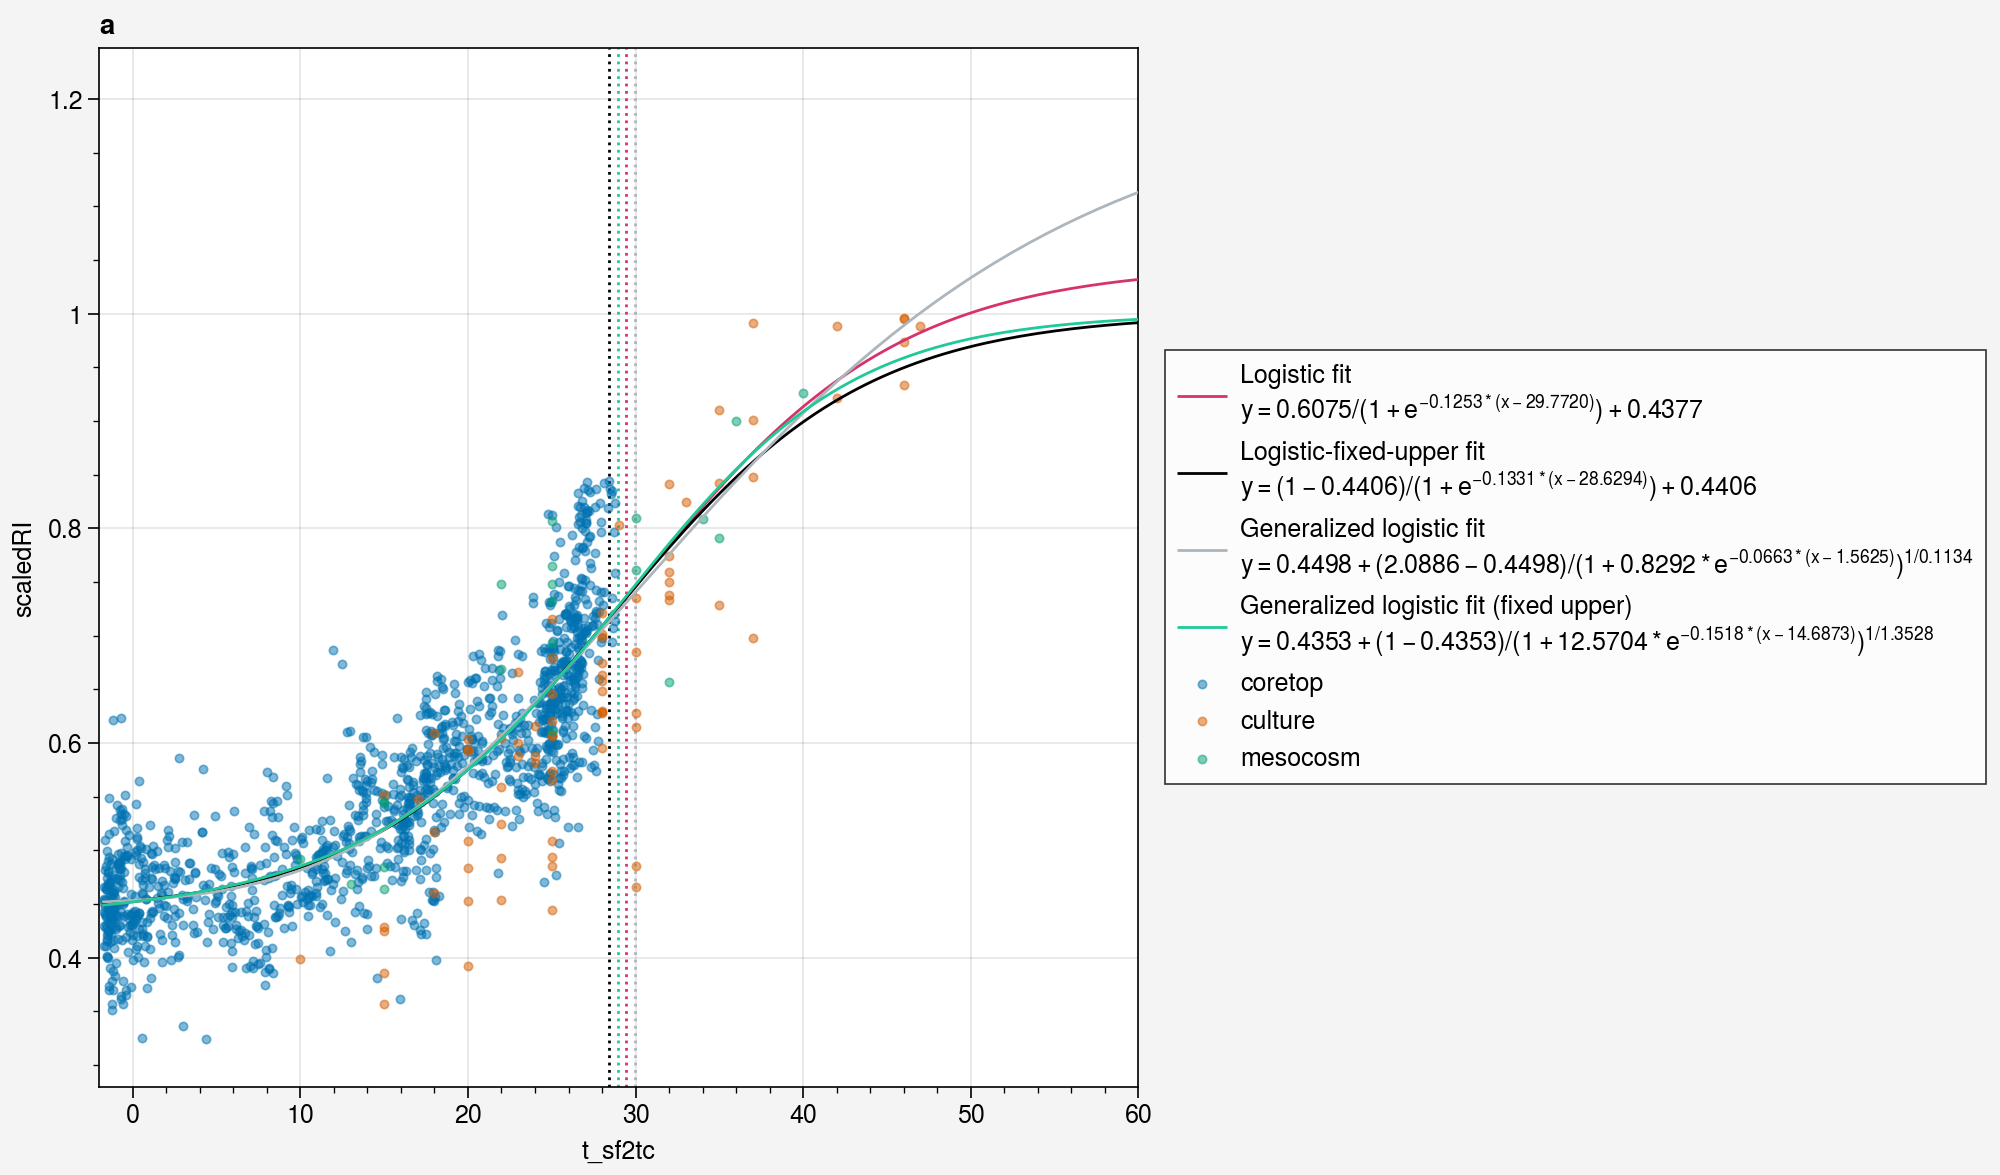

In [30]:
fig, axs = plot.subplots(width=10)

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax = axs[0]
    ax.scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
               m='.',alpha=0.5,zorder=3)
    
### curve fit
from scipy.optimize import curve_fit

nonnan_idx = combined_df['t_sf2tc'].notna() & combined_df['scaledRI'].notna()
sel_X = combined_df['t_sf2tc'][nonnan_idx].values
sel_Y = combined_df['scaledRI'][nonnan_idx].values
XX = np.linspace(sel_X.min(), 100, 200)
### use logistic function for curve fitting
popt, pcov = curve_fit(
    logistic,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf]))
fitted_x0 = popt[0]
fitted_k = popt[1]
fitted_L = popt[2]
fitted_b = popt[3]
axs[0].plot(XX, logistic(XX, *popt), 
            color='pink7', lw=1, 
            label=f'Logistic fit\n$y = {fitted_L:.4f} / (1 + e^{{-{fitted_k:.4f} * (x - {fitted_x0:.4f})}}) + {fitted_b:.4f}$',
            zorder=4)

## define inflection point with differential
def plot_inflection_point(ax, x_vals, y_vals,sel_color='k',sel_linestyle='--'):
    """Plot the inflection point on the given axis."""
    # Compute numerical first and second derivatives
    dy_dx = np.gradient(y_vals, x_vals)
    d2y_dx2 = np.gradient(dy_dx, x_vals)

    # Find zero crossing in second derivative
    sign_change = np.where(np.diff(np.sign(d2y_dx2)))[0]
    
    # Get estimated inflection x value
    if sign_change.size > 0:
        inflection_idx = sign_change[0]
        inflection_x = x_vals[inflection_idx]
        ax.axvline(inflection_x, color=sel_color, ls=sel_linestyle, lw=1,)
        return inflection_x
    else:
        print("No inflection point found")
        return None

inflection_x = plot_inflection_point(axs[0], XX, logistic(XX, *popt),
                                    sel_color='pink7', sel_linestyle=':')

### use logistic_fixed_upper function for curve fitting
popt_fixed, pcov_fixed = curve_fit(
    logistic_fixed_upper,
    sel_X,sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf]))
fitted_x0_fixed = popt_fixed[0]
fitted_k_fixed = popt_fixed[1]
fitted_b_fixed = popt_fixed[2]
axs[0].plot(XX, logistic_fixed_upper(XX, *popt_fixed), 
            color='k', lw=1, 
            label=f'Logistic-fixed-upper fit\n$y = (1-{fitted_b_fixed:.4f}) / (1 + e^{{-{fitted_k_fixed:.4f} * (x - {fitted_x0_fixed:.4f})}}) + {fitted_b_fixed:.4f}$',
            zorder=4)

inflection_x_fixed = plot_inflection_point(axs[0], XX, logistic_fixed_upper(XX, *popt_fixed),
                                             sel_color='k', sel_linestyle=':')

### use the generalized logistic function for curve fitting
popt_gen, pcov_gen = curve_fit(
    generalized_logistic_model,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen = popt_gen[0]
fitted_A_gen = popt_gen[1]
fitted_K_gen = popt_gen[2]
fitted_B_gen = popt_gen[3]
fitted_v_gen = popt_gen[4]
fitted_Q_gen = popt_gen[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen), 
            color='gray5', lw=1, 
            label=f'Generalized logistic fit\n$y = {fitted_A_gen:.4f} + ({fitted_K_gen:.4f} - {fitted_A_gen:.4f}) / (1 + {fitted_Q_gen:.4f} * e^{{-{fitted_B_gen:.4f} * (x - {fitted_x0_gen:.4f})}})^{{1/{fitted_v_gen:.4f}}}$',
            zorder=4)

inflection_x_gen = plot_inflection_point(axs[0], XX, generalized_logistic_model(XX, *popt_gen),
                                         sel_color='gray5', sel_linestyle=':')

### use the generalized logistic function with fixed upper limit for curve fitting by setting K = 1
popt_gen_fixed, pcov_gen_fixed = curve_fit(
    generalized_logistic_model_fixed_upper,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed = popt_gen_fixed[0]
fitted_A_gen_fixed = popt_gen_fixed[1]
fitted_B_gen_fixed = popt_gen_fixed[2]
fitted_v_gen_fixed = popt_gen_fixed[3]
fitted_Q_gen_fixed = popt_gen_fixed[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed), 
            color='teal5', lw=1, 
            label=f'Generalized logistic fit (fixed upper)\n$y = {fitted_A_gen_fixed:.4f} + (1 - {fitted_A_gen_fixed:.4f}) / (1 + {fitted_Q_gen_fixed:.4f} * e^{{-{fitted_B_gen_fixed:.4f} * (x - {fitted_x0_gen_fixed:.4f})}})^{{1/{fitted_v_gen_fixed:.4f}}}$',
            zorder=4)

inflection_x_gen_fixed = plot_inflection_point(axs[0], XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed),
                                               sel_color='teal5', sel_linestyle=':')

axs.format(
    xlim=(-2,60),
    # ylim=(0.3,0.6)
)

print(f'Inflection point (logistic): {inflection_x:.4f}')
print(f'Inflection point (logistic-fixed-upper): {inflection_x_fixed:.4f}')
print(f'Inflection point (generalized logistic): {inflection_x_gen:.4f}')
print(f'Inflection point (generalized logistic-fixed-upper): {inflection_x_gen_fixed:.4f}')

ax.legend(loc='r',ncols=1)

# Calibration posteriors

## jnt_cul_meso

In [46]:

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,

}

stan_file_name = 'gen_logi_culmeso'
gen_logi_cul_meso_post_ds, diag = culRIB.get_posterior(data, 
                                                  stan_file_name,
                                                  temptype='cultureT')


# Save posteriors
culRIB.save_posterior(gen_logi_cul_meso_post_ds)

08:25:50 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:25:52 - cmdstanpy - INFO - CmdStan done processing.
08:25:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 1.2853, but must be in the interval [0, 1] (in 'gen_logi_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_culmeso.stan', line 40, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 1.30225, but must be in the interval [0, 1] (in 'gen_logi_culmeso.stan', line 29, column 2 to column 30)
Exception: beta_lpdf: Random variable is 18.8809, but must be in the interval [0, 1] (in 'gen_logi_culmeso.stan', line 29, column 2 to column 30)
	Exception: beta_lpdf: Random variable is 1.2786, but must be in the interval [0, 1] (in 'gen_logi_culmeso.stan', line 29, column 2 to column 30)
Exception: beta_lpdf: Random variable is 1.81471, but must be in the interval [0, 1] (in 'gen_logi_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_


Sampling completed in 2.4 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/gen_logi_culmeso_cultureT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/gen_logi_culmeso_cultureT.nc')

In [47]:
gen_logi_cul_meso_post_ds.priors

['t0_culmeso: normal(30, 10) T[-1.8, ]',
 'k_culmeso: normal(0, 0.25)',
 'Q_culmeso: normal(1, 5) T[0, ]',
 'v_culmeso: normal(1, 5) T[0, ]',
 'b_culmeso: beta(2, 5)',
 'sigma_scaledRI_cul: cauchy(0, 0.1)',
 'sigma_scaledRI_meso: cauchy(0, 0.1)',
 'scaledRI_cul: normal(mu_scaledRI_cul, sigma_scaledRI_cul)',
 'scaledRI_meso: normal(mu_scaledRI_meso, sigma_scaledRI_meso)']

Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': ['v_culmeso'], 'Q': ['Q_culmeso'], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b', 'v', 'Q']


(<Figure size 900x700 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='v'>, <AxesSubplot:xlabel='Q'>,
         <AxesSubplot:>]], dtype=object))

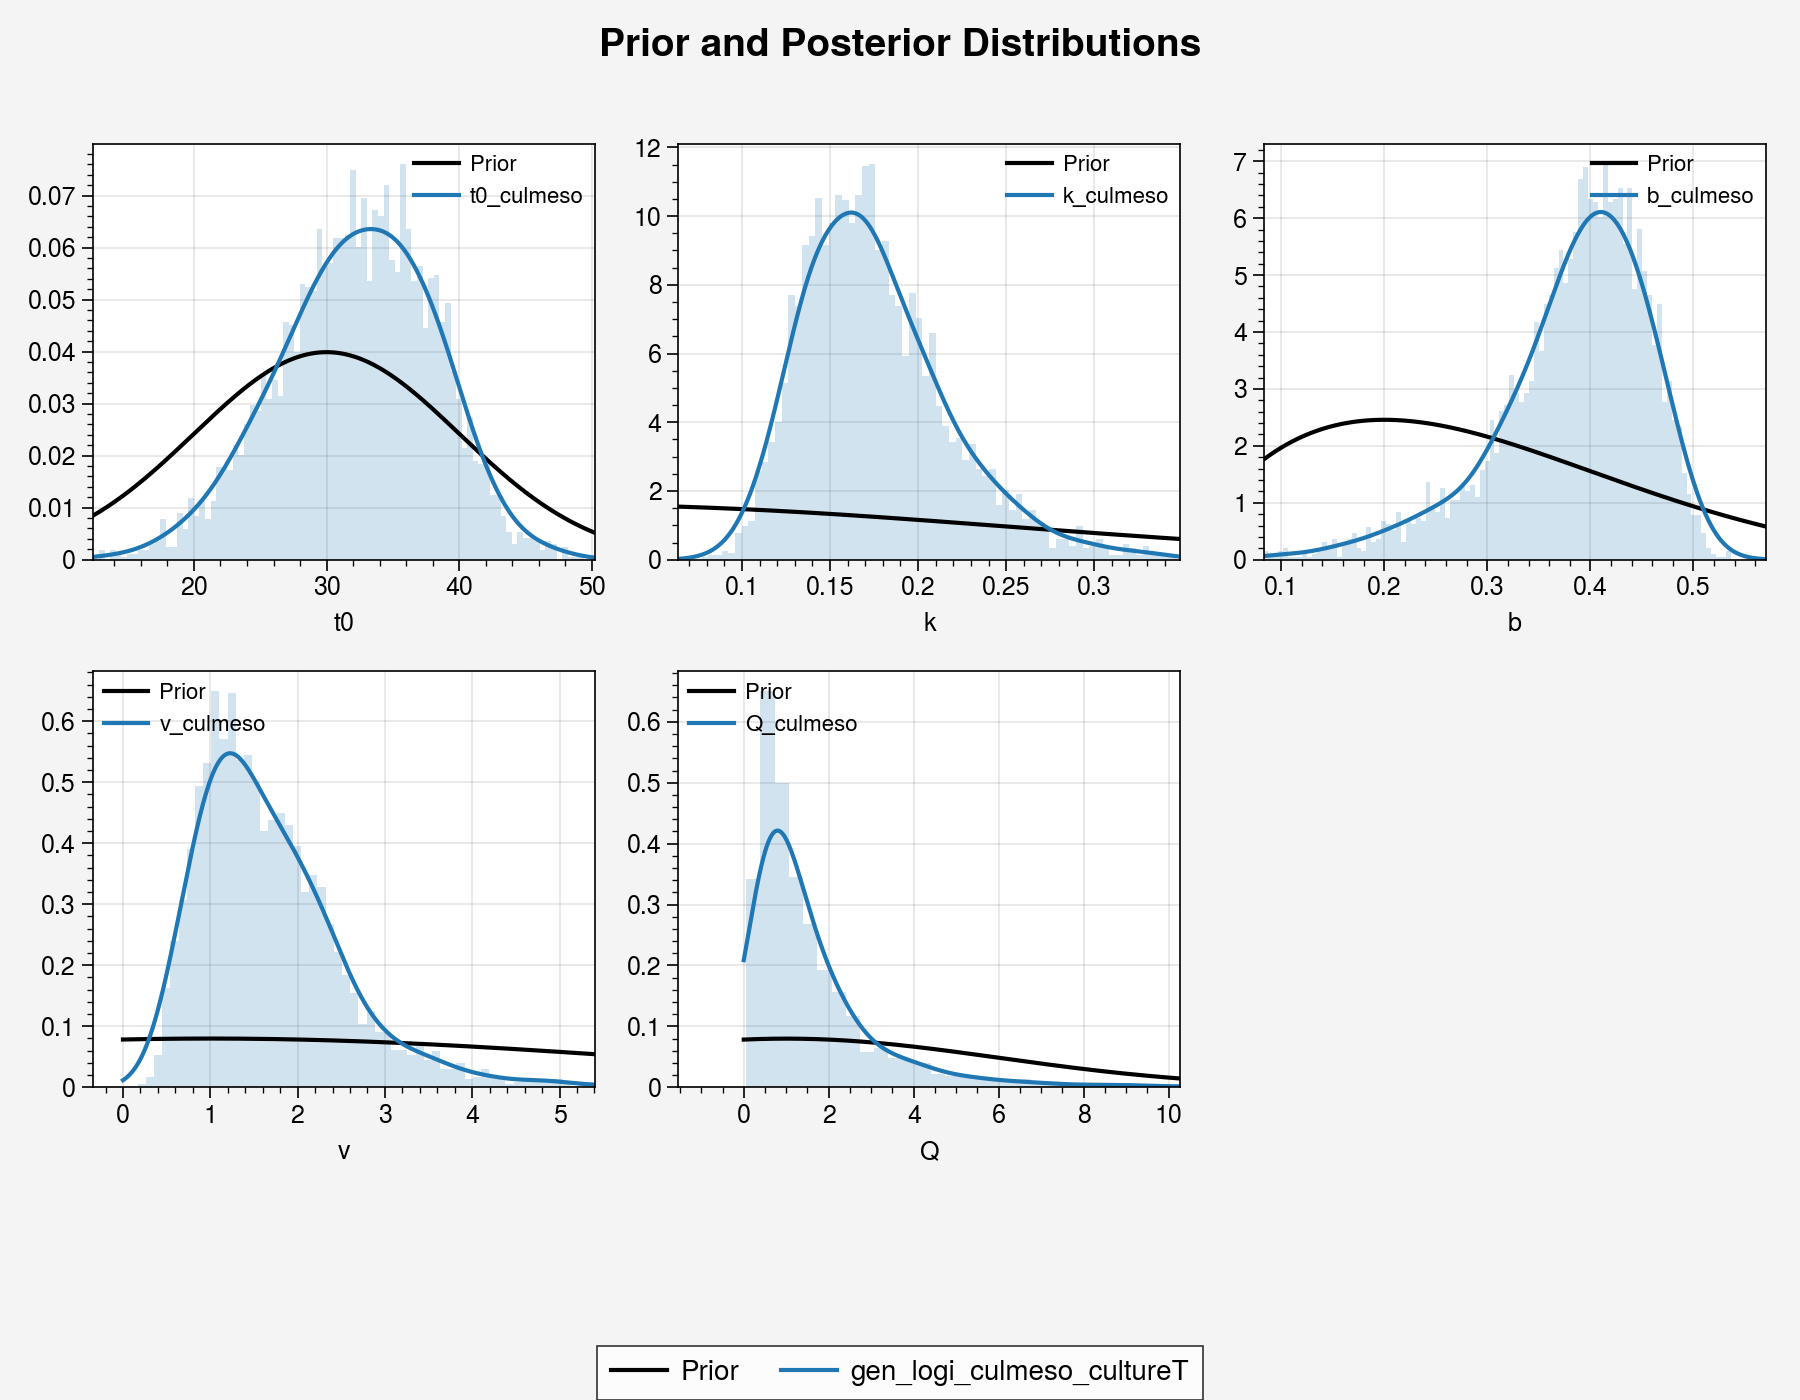

In [48]:
priors = gen_logi_cul_meso_post_ds.attrs['priors']
dv.plot_prior_distributions(
    priors,
    posterior_datasets=[gen_logi_cul_meso_post_ds]
)

In [49]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
}

stan_file_name = 'jnt_cul_meso'
jnt_cul_meso_post_ds, diag = culRIB.get_posterior(data, 
                                                  stan_file_name,
                                                  temptype='cultureT')


# Save posteriors
culRIB.save_posterior(jnt_cul_meso_post_ds)

08:26:55 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:26:55 - cmdstanpy - INFO - CmdStan done processing.
08:26:55 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.20948, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso.stan', line 40, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 2.69441, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
Exception: beta_lpdf: Random variable is 7.06601, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.00113, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
Exception: normal_lpdf: Scale parameter 


Sampling completed in 0.4 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_cultureT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_cultureT.nc')

In [50]:
jnt_cul_meso_post_ds

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso              (draw) float64 31.29 29.29 30.49 ... 29.63 30.03
    k_culmeso               (draw) float64 0.1631 0.1558 ... 0.1381 0.1628
    b_culmeso               (draw) float64 0.4635 0.3907 ... 0.3983 0.4366
    sigma_scaledRI_cul      (draw) float64 0.07887 0.08478 ... 0.07524 0.07075
    sigma_scaledRI_meso     (draw) float64 0.1097 0.1167 ... 0.1269 0.09537
    sigma_scaledRI_culmeso  (draw) float64 0.08625 0.0924 ... 0.08863 0.07658
Attributes: (12/21)
    stan_model_name:     jnt_cul_meso
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-07-28T08:26:55.560737
    run_duration (sec):  0.38
    temptype:            cultureT
    ...                  ...
    scaledRI_meso_std:   0.13845152852523196
    scaledRI_meso_min:   0.4640795035
    scaledRI_meso_max:   0.92620505575
    scaledRI_meso_len:   21
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...
    filename:            jnt_cul_meso_cultureT

In [51]:
# Sample 500 draws from posterior
post_ds = gen_logi_cul_meso_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmeso', 'b_culmeso', 'k_culmeso', 'v_culmeso', 'Q_culmeso']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)

# Create x-axis (temperature or predictor) values
x_vals = np.linspace(0, 50, 500)

# Initialize matrix for storing ensemble predictions
ensemble = np.zeros((n_draws, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        row['t0_culmeso'],
        row['b_culmeso'],
        row['k_culmeso'],
        row['v_culmeso'],
        row['Q_culmeso']
    )
    
# Compute percentiles
lower_bound = np.percentile(ensemble, 5, axis=0)
upper_bound = np.percentile(ensemble, 95, axis=0)
median_curve = np.percentile(ensemble, 50, axis=0)

### jnt_cul_meso_post_ds
post_ds_jnt = jnt_cul_meso_post_ds
n_draws_jnt = 500
posterior_df_jnt = post_ds_jnt[['t0_culmeso','k_culmeso','b_culmeso']].to_dataframe().reset_index()
sampled_draws_jnt = posterior_df_jnt.sample(n=n_draws_jnt, replace=False, random_state=42).reset_index(drop=True)

# Initialize matrix for storing ensemble predictions
ensemble_jnt = np.zeros((n_draws_jnt, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws_jnt):
    row = sampled_draws_jnt.loc[i]
    ensemble_jnt[i, :] = logistic_fixed_upper(
        x_vals,
        row['t0_culmeso'],
        row['k_culmeso'],
        row['b_culmeso']
    )

# Compute percentiles
lower_bound_jnt = np.percentile(ensemble_jnt, 5, axis=0)
upper_bound_jnt = np.percentile(ensemble_jnt, 95, axis=0)
median_curve_jnt = np.percentile(ensemble_jnt, 50, axis=0)


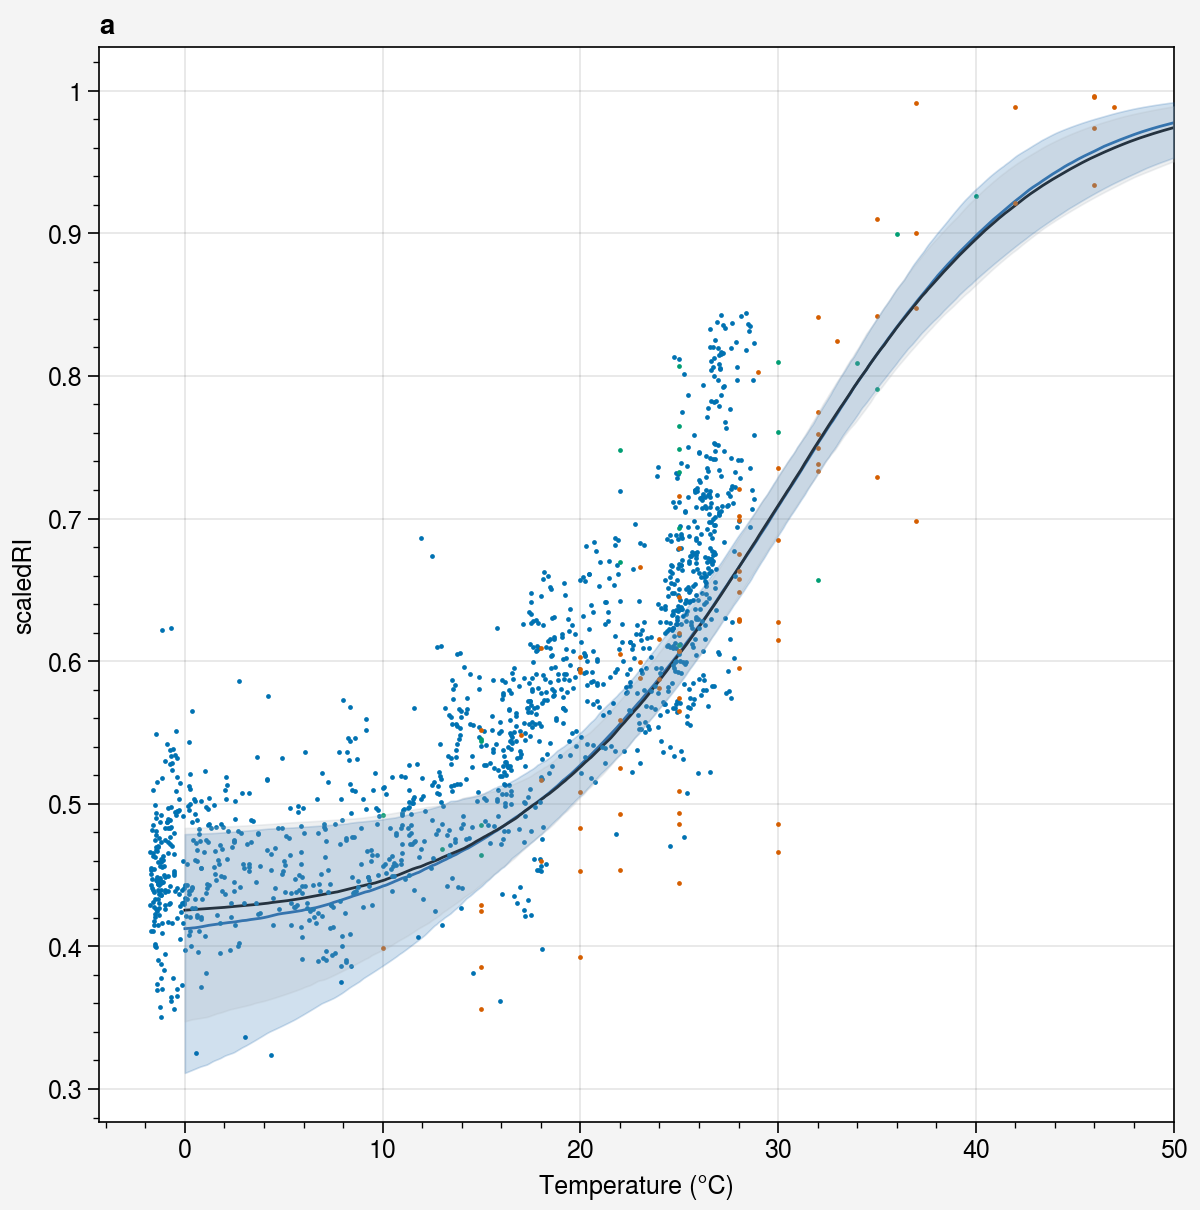

In [52]:
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)



### extract posteriors from jnt_cul_meso_post_ds
post_ds_jnt = jnt_cul_meso_post_ds
x0_jnt_median = post_ds_jnt['t0_culmeso'].median(dim='draw').item()
k_jnt_median  = post_ds_jnt['k_culmeso'].median(dim='draw').item()
b_jnt_median  = post_ds_jnt['b_culmeso'].median(dim='draw').item()

y_vals_jnt = logistic_fixed_upper(x_vals, x0_jnt_median, k_jnt_median, b_jnt_median)

# Plot
fig, axs = plot.subplots(width=6)
axs[0].plot(x_vals, median_curve, color='blue9', lw=1, label='Fitted model')
axs[0].fill_between(x_vals, lower_bound, upper_bound, 
                   color='blue9', alpha=0.2, label='95% CI',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt, color='k', lw=1, label='Joint model')
axs[0].fill_between(x_vals, lower_bound_jnt, upper_bound_jnt, 
                   color='gray5', alpha=0.2, label='95% CI (joint model)',
                   zorder=5)
axs[0].set_xlabel('Temperature (°C)')

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    axs[0].scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
                   m='.', s=5, zorder=3)

## hier_crtp | prior approximation

In [58]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_cul_meso_post_ds['t0_culmeso'].mean(dim="draw").item()
prior_sd_t0 = gen_logi_cul_meso_post_ds['t0_culmeso'].std(dim="draw").item()

prior_mean_k = gen_logi_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_hier_crtp_univ_priorApprox'
gen_logi_hier_crtp_univ_prior_approx_post_ds, diag = culRIB.get_posterior(
    data_normal_prior,
    stan_file_name,
    temptype='thermoT'
)
culRIB.save_posterior(gen_logi_hier_crtp_univ_prior_approx_post_ds)


08:29:07 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:30:12 - cmdstanpy - INFO - CmdStan done processing.
08:30:12 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to


Sampling completed in 64.4 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
344 of 1000 (34.40%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/gen_logi_hier_crtp_univ_priorApprox_thermoT.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/gen_logi_hier_crtp_univ_priorApprox_thermoT.nc')

In [ ]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_cul_meso_post_ds['t0_culmeso'].mean(dim="draw").item()
prior_sd_t0 = gen_logi_cul_meso_post_ds['t0_culmeso'].std(dim="draw").item()

prior_mean_k = gen_logi_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = gen_logi_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = gen_logi_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = gen_logi_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

prior_mean_Q = np.log(gen_logi_cul_meso_post_ds["Q_culmeso"]).mean(dim="draw").item()
prior_sd_Q = np.log(gen_logi_cul_meso_post_ds["Q_culmeso"]).std(dim="draw").item()

prior_mean_v = np.log(gen_logi_cul_meso_post_ds["v_culmeso"]).mean(dim="draw").item()
prior_sd_v = np.log(gen_logi_cul_meso_post_ds["v_culmeso"]).std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_hier_crtp_univ_priorApprox'
gen_logi_hier_crtp_univ_prior_approx_post_ds_sst, diag = culRIB.get_posterior(
    data_normal_prior,
    stan_file_name,
    temptype='sst'
)
culRIB.save_posterior(gen_logi_hier_crtp_univ_prior_approx_post_ds_sst)


11:42:16 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

11:43:25 - cmdstanpy - INFO - CmdStan done processing.
11:43:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_hier_crtp_univ_priorApprox.stan', line 42, column 2 to


Sampling completed in 69.5 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
792 of 1000 (79.20%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/gen_logi_hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/gen_logi_hier_crtp_univ_priorApprox_sst.nc')

In [55]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
                                                                 stan_file_name,
                                                                 temptype='thermoT',)
# Save posteriors
culRIB.save_posterior(hier_crtp_univ_prior_approx_post_ds)

###################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

data_normal_prior = {
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_sst_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
                                                                 stan_file_name,
                                                                 temptype='sst',)
# Save posteriors
culRIB.save_posterior(hier_crtp_sst_univ_prior_approx_post_ds)

08:27:33 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:27:37 - cmdstanpy - INFO - CmdStan done processing.
08:27:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Consider re-running with show_console=True if the above output is unclear!



Sampling completed in 2.1 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc')

In [59]:
### calculate "median_curve_gen_logi_crtp"
post_ds_gen_logi_crtp = gen_logi_hier_crtp_univ_prior_approx_post_ds
n_draws_gen_logi_crtp = 500
posterior_df_gen_logi_crtp = post_ds_gen_logi_crtp[['t0_crtp','k_crtp','b_crtp','v_crtp','Q_crtp']].to_dataframe().reset_index()
sampled_draws_gen_logi_crtp = posterior_df_gen_logi_crtp.sample(n=n_draws_gen_logi_crtp, replace=False, random_state=42).reset_index(drop=True) 

ensemble_gen_logi_crtp = np.zeros((n_draws_gen_logi_crtp, len(x_vals)))

for i in range(n_draws_gen_logi_crtp):
    row = sampled_draws_gen_logi_crtp.loc[i]
    ensemble_gen_logi_crtp[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        row['t0_crtp'],
        row['b_crtp'],
        row['k_crtp'],
        row['v_crtp'],
        row['Q_crtp']
    )

# Compute percentiles
lower_bound_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 5, axis=0)
upper_bound_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 95, axis=0)
median_curve_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 50, axis=0)

### hier_crtp_univ_prior_approx_post_ds
post_ds_jnt_crtp = hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df_jnt_crtp = post_ds_jnt_crtp[['t0_crtp','k_crtp','b_crtp']].to_dataframe().reset_index()
sampled_draws_jnt_crtp = posterior_df_jnt_crtp.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)

# Initialize matrix for storing ensemble predictions
ensemble_jnt_crtp = np.zeros((n_draws, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws):
    row = sampled_draws_jnt_crtp.loc[i]
    ensemble_jnt_crtp[i, :] = logistic_fixed_upper(
        x_vals,
        row['t0_crtp'],
        row['k_crtp'],
        row['b_crtp']
    )

# Compute percentiles
lower_bound_jnt_crtp = np.percentile(ensemble_jnt_crtp, 5, axis=0)
upper_bound_jnt_crtp = np.percentile(ensemble_jnt_crtp, 95, axis=0)
median_curve_jnt_crtp = np.percentile(ensemble_jnt_crtp, 50, axis=0)

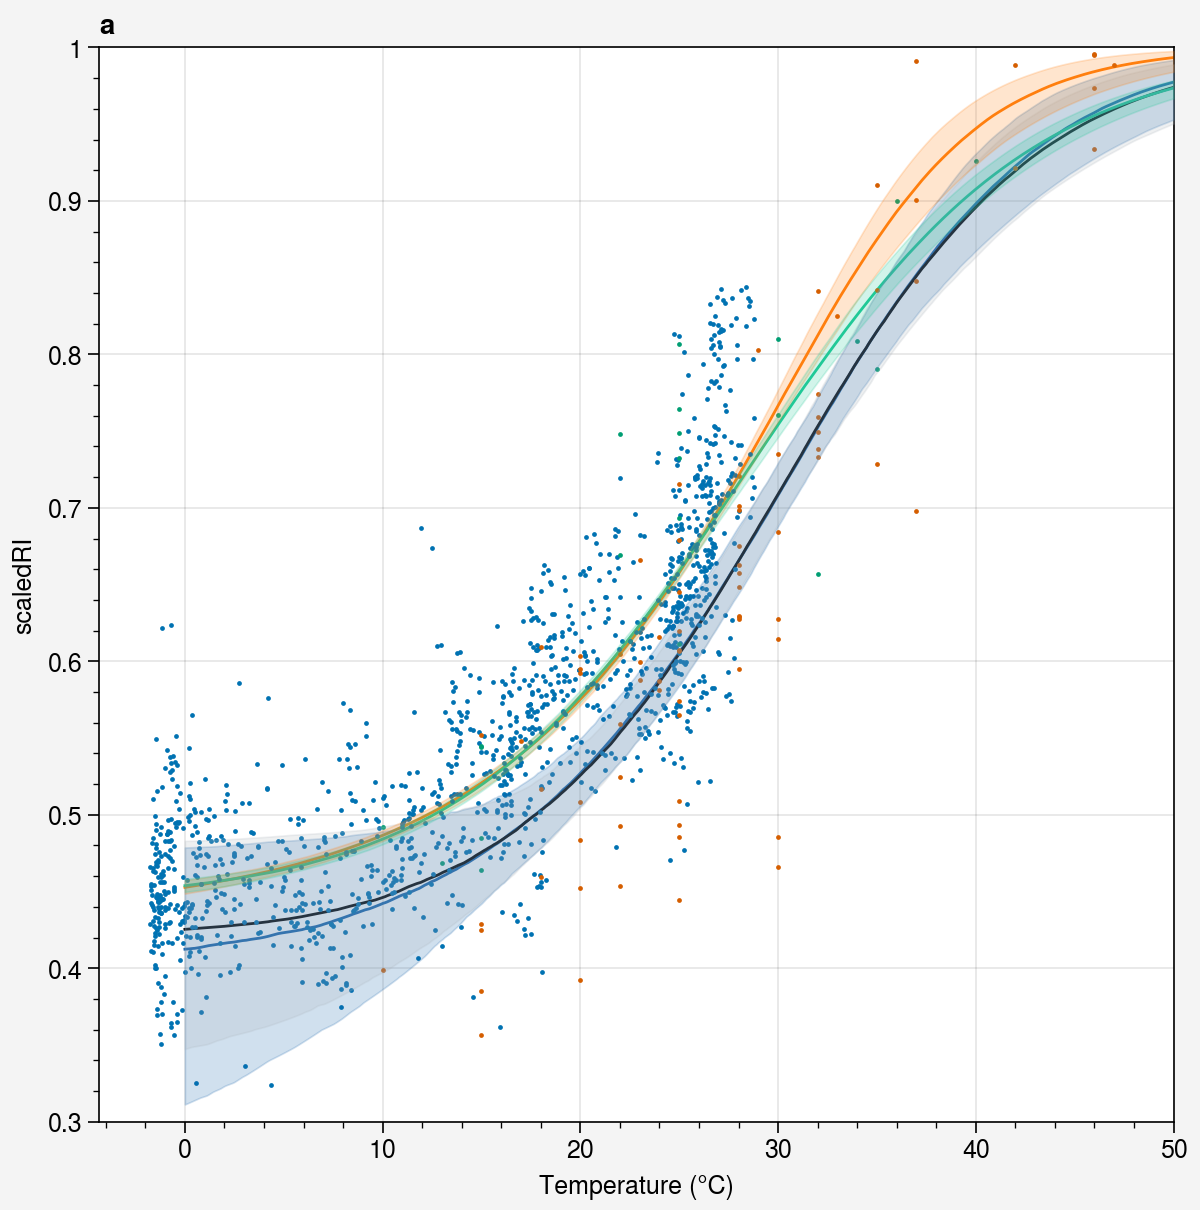

In [60]:
# Create 1000 ensemble members of S-curve from the posterior samples



# Plot
fig, axs = plot.subplots(width=6)
axs[0].plot(x_vals, median_curve, color='blue9', lw=1, label='Fitted model')
axs[0].fill_between(x_vals, lower_bound, upper_bound, 
                   color='blue9', alpha=0.2, label='95% CI',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt, color='k', lw=1, label='Joint model')
axs[0].fill_between(x_vals, lower_bound_jnt, upper_bound_jnt, 
                   color='gray5', alpha=0.2, label='95% CI (joint model)',
                   zorder=5)

axs[0].plot(x_vals, median_curve_gen_logi_crtp, color='tab:orange', lw=1, label='Hierarchical model (univariate prior approx.)')
axs[0].fill_between(x_vals, lower_bound_gen_logi_crtp, upper_bound_gen_logi_crtp, 
                   color='tab:orange', alpha=0.2, label='95% CI (hierarchical model)',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt_crtp, color='teal5', lw=1, label='Hierarchical model (univariate prior approx. SST)')
axs[0].fill_between(x_vals, lower_bound_jnt_crtp, upper_bound_jnt_crtp, 
                   color='teal5', alpha=0.2, label='95% CI (hierarchical model SST)',
                   zorder=5)

axs[0].set_xlabel('Temperature (°C)')

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    axs[0].scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
                   m='.', s=5, zorder=3)
    
# y_linear_schouten02 = predictTEXfromSST(x_vals, method_name='schouten02')
# y_kim10 = predictTEXfromSST(x_vals,method_name='kim2010_tex86H')

# ax = axs[0]
# ax.plot(x_vals, y_linear_schouten02, color='red9', lw=1, label='Schouten et al. (2002) linear fit')
# ax.plot(x_vals, y_kim10, color='green9', lw=1, label='Kim et al. (2010) linear fit')

axs.format(
    ylim=(0.3, 1),
)

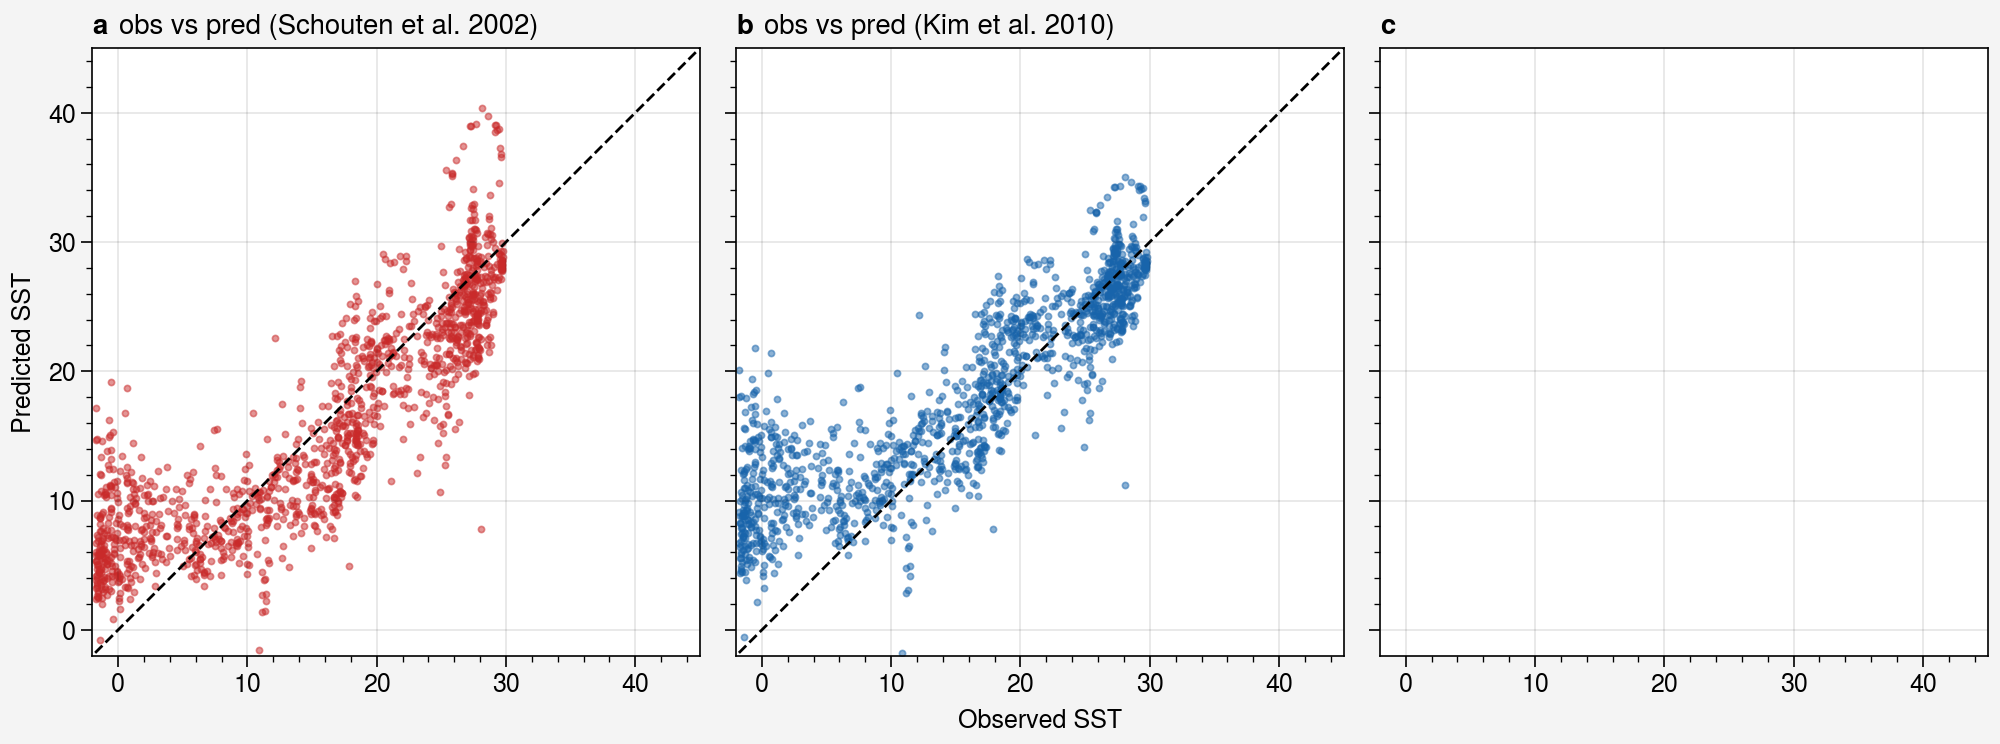

In [62]:
fig, axs = plot.subplots(width=10,ncols=3)

plot_data = coretop_df
plot_data['pred_sst_schouten02'] = predictSSTfromTEX(plot_data['tex_median'], method_name='schouten02')

plot_x = plot_data['sst']
plot_y = plot_data['pred_sst_schouten02']
axs[0].scatter(plot_x, plot_y, c='red9', s=5, alpha=0.5, label='Schouten et al. (2002) linear fit')
axs[0].plot([-5, 50], [-5, 50], color='black', lw=1, ls='--', label='y=x')
axs[0].format(
    ltitle='obs vs pred (Schouten et al. 2002)',
    xlabel='Observed SST',
    ylabel='Predicted SST'
)

plot_data['pred_sst_kim10'] = predictSSTfromTEX(plot_data['tex_median'], method_name='kim2010_tex86H')
plot_x = plot_data['sst']
plot_y = plot_data['pred_sst_kim10']
axs[1].scatter(plot_x, plot_y, c='blue9', s=5, alpha=0.5, label='Kim et al. (2010) linear fit')
axs[1].plot([-5, 50], [-5, 50], color='black', lw=1, ls='--', label='y=x')
axs[1].format(
    ltitle='obs vs pred (Kim et al. 2010)',
    xlabel='Observed SST',
    ylabel='Predicted SST'
)

axs.format(
    xlim=(-2,45),
    ylim=(-2,45),
)

## jnt_cul_meso_crtp

In [63]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_post_ds, diag = culRIB.get_posterior(data, 
                                                       stan_file_name,
                                                       temptype='thermoT')
display(jnt_cul_meso_crtp_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_crtp_post_ds)

##########################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
                                                           stan_file_name,
                                                           temptype='sst')
display(jnt_cul_meso_crtp_sst_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_crtp_sst_post_ds)


08:32:06 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

08:32:12 - cmdstanpy - INFO - CmdStan done processing.
08:32:12 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_crtp.stan', line 42, column 2 to column 65)
Exception: beta_lpdf: Random variable is 3.25794, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.39111, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.54016, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.51299, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception


Sampling completed in 3.6 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmesocore       (draw) float64 30.28 30.11 30.13 ... 30.04 29.96 29.94
    k_culmesocore        (draw) float64 0.1214 0.1173 0.1135 ... 0.1247 0.1193
    b_culmesocore        (draw) float64 0.4396 0.4351 0.4342 ... 0.4364 0.4366
    sigma_scaledRI_cul   (draw) float64 0.08574 0.08758 ... 0.08915 0.08734
    sigma_scaledRI_meso  (draw) float64 0.0844 0.07032 ... 0.08504 0.07946
    sigma_scaledRI_crtp  (draw) float64 0.05531 0.05643 ... 0.05659 0.05405
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-07-28T08:32:12.823409
    run_duration (sec):  3.56
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5550564678176569
    scaledRI_crtp_std:   0.1048080081889685
    scaledRI_crtp_min:   0.32373191325
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1348
    priors:              ['t0_culmesocore: normal(30, 10) T[-1.8, ]', 'k_culm...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc')

## jnt_cul_meso_hier_crtp

In [64]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()


### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_post_ds, diag = culRIB.get_posterior(data, 
                                                            stan_file_name,
                                                            temptype='thermoT',)
display(jnt_cul_meso_hier_crtp_post_ds)
# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_post_ds)

###########################################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
                                                            stan_file_name,
                                                            temptype='sst',)
display(jnt_cul_meso_hier_crtp_sst_post_ds)
# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_post_ds)

08:32:12 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

08:32:49 - cmdstanpy - INFO - CmdStan done processing.
08:32:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_hier_crtp.stan', line 78, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_hier_crtp.stan', line 78, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_hier_crtp.stan', line 78, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_hier_crtp.stan', line 62, column 4 to column 65)
Consider re-running with show_console=True if the above output is unclear!
08:32:49 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 11 divergent transitions (1.1%)
	Chain 3 had 8 divergent transitions (0.8%)
	Chain 4 had 13 divergent transitions (1.3%)
	Use the "diagnose()" method on the CmdStanMCMC object t


Sampling completed in 22.5 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
32 of 1000 (3.20%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso           (draw) float64 30.15 30.15 29.79 ... 30.11 30.06 29.11
    k_culmeso            (draw) float64 0.1501 0.1587 0.1608 ... 0.1664 0.1343
    b_culmeso            (draw) float64 0.4292 0.4169 0.4308 ... 0.4427 0.3808
    t0_crtp              (draw) float64 30.1 30.15 29.69 ... 30.29 29.77 29.96
    k_crtp               (draw) float64 0.1161 0.118 0.1142 ... 0.121 0.1216
    b_crtp               (draw) float64 0.4357 0.4359 0.4296 ... 0.4376 0.4387
    sigma_t0_culmeso     (draw) float64 0.07594 0.06035 0.2567 ... 0.2133 4.468
    sigma_k_culmeso      (draw) float64 0.09535 0.1265 0.4258 ... 0.03489 0.4794
    sigma_b_culmeso      (draw) float64 0.4007 0.2023 0.00985 ... 0.01255 0.6682
    sigma_scaledRI_cul   (draw) float64 0.06992 0.07443 ... 0.08091 0.06951
    sigma_scaledRI_meso  (draw) float64 0.1228 0.1215 0.08613 ... 0.1156 0.1033
    sigma_scaledRI_crtp  (draw) float64 0.05472 0.05511 ... 0.05383 0.05675
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_hier_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-07-28T08:32:49.487009
    run_duration (sec):  22.47
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5550564678176569
    scaledRI_crtp_std:   0.1048080081889685
    scaledRI_crtp_min:   0.32373191325
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1348
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc


PosixPath('/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc')

In [96]:
importlib.reload(dv)

<module 'culRIBayesian.dataviz_utils' from '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/dataviz_utils.py'>

Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_crtp', 'k_culmeso'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_crtp', 'v_culmeso'], 'Q': ['Q_crtp', 'Q_culmeso'], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
['t0', 'k', 'b', 'v', 'Q']


(<Figure size 900x800 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='v'>, <AxesSubplot:xlabel='Q'>,
         <AxesSubplot:>]], dtype=object))

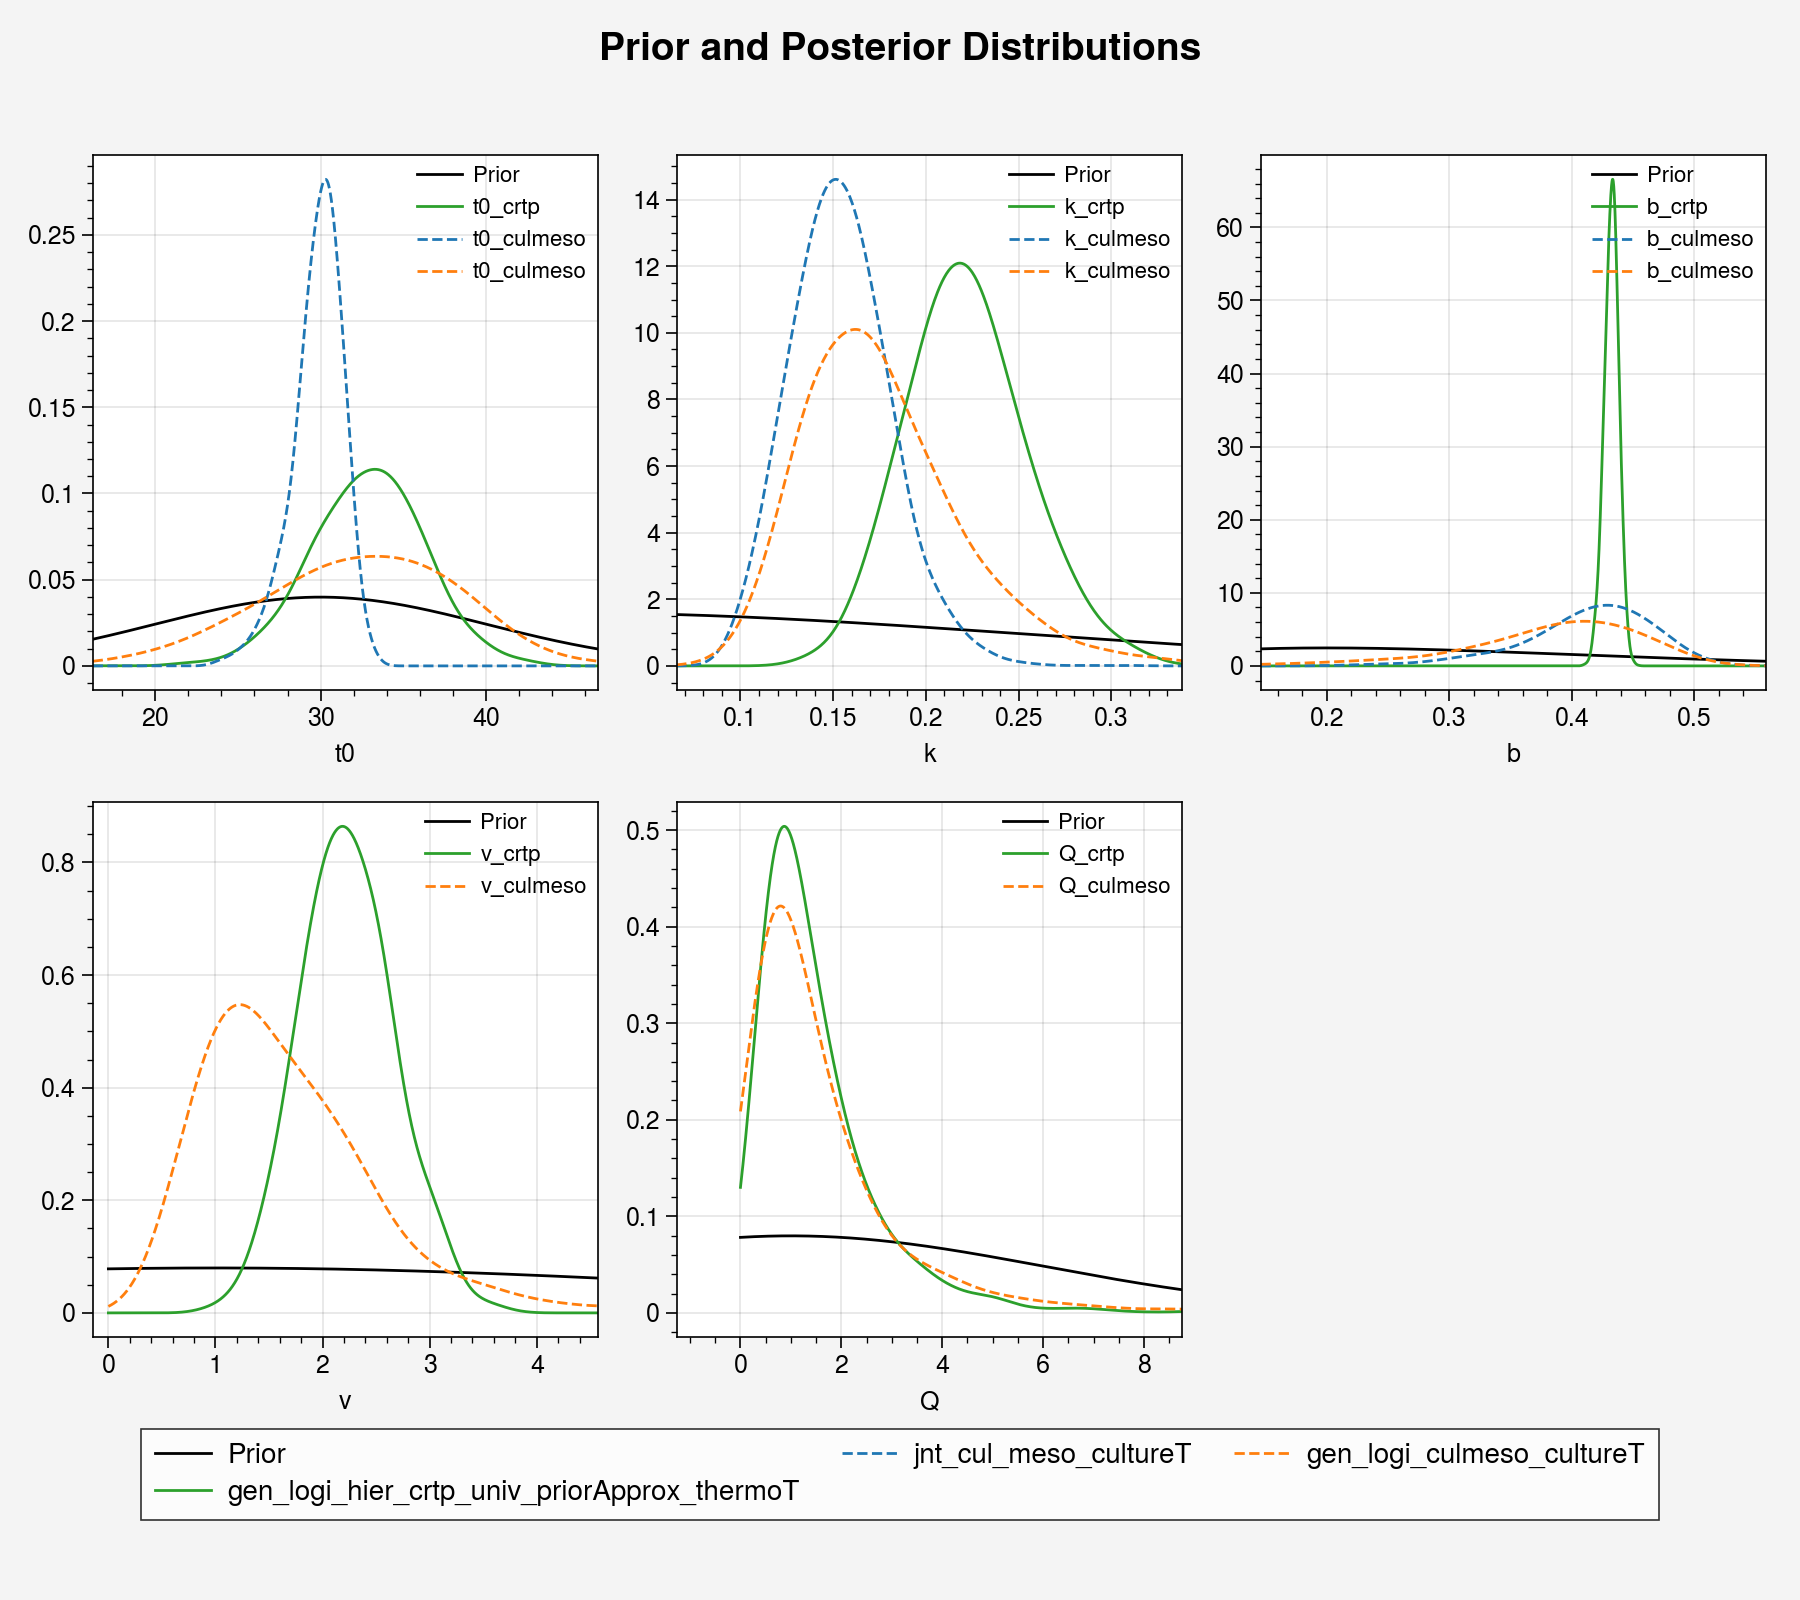

In [97]:
priors = gen_logi_cul_meso_post_ds.attrs['priors']
dv.plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                gen_logi_cul_meso_post_ds,
                                # jnt_cul_meso_crtp_post_ds,
                                gen_logi_hier_crtp_univ_prior_approx_post_ds,
                                # jnt_cul_meso_crtp_sst_post_ds,
                                # jnt_cul_meso_hier_crtp_post_ds,
                                # jnt_cul_meso_hier_crtp_sst_post_ds,
                                # hier_crtp_univ_prior_logmixture_post_ds,
                                # hier_crtp_univ_prior_approx_post_ds,
                                # hier_crtp_sst_univ_prior_logmixture_post_ds,
                                # hier_crtp_sst_univ_prior_approx_post_ds
                                ],
                            use_linestyle_by_param=True,
                            show_histogram=False,
                            set_linewidth=1,
                            set_fig_height_factor=4
                            )

## jnt_cul_meso_hier

In [36]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    # "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
                                                                        stan_file_name,
                                                                        temptype='thermoT')
display(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

#####################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    # "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
                                                                            stan_file_name,
                                                                            temptype='sst',)
display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

10:00:01 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

10:02:18 - cmdstanpy - INFO - CmdStan done processing.
10:02:18 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 66)
	E


Sampling completed in 43.3 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
25 of 1000 (2.50%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.88 29.95 30.26 ... 28.13 29.89
    k_culmeso               (draw) float64 0.1487 0.1497 ... 0.1168 0.1403
    b_culmeso               (draw) float64 0.4176 0.4248 ... 0.3572 0.3859
    t0_crtp                 (draw) float64 27.8 28.8 28.62 ... 28.27 28.39 28.25
    k_crtp                  (draw) float64 0.09847 0.1214 0.1192 ... 0.116 0.112
    b_crtp                  (draw) float64 0.4405 0.46 0.4576 ... 0.4506 0.4529
    ...                      ...
    sigma_t0_culmeso        (draw) float64 1.759 1.043 1.5 ... 0.3777 2.659
    sigma_k_culmeso         (draw) float64 0.1695 0.2016 1.667 ... 0.02146 0.713
    sigma_b_culmeso         (draw) float64 1.176 0.03228 ... 0.1242 0.4514
    sigma_scaledRI_cul      (draw) float64 0.09157 0.06821 ... 0.07706 0.0747
    sigma_scaledRI_meso     (draw) float64 0.1337 0.08 0.09573 ... 0.0795 0.1223
    sigma_scaledRI_crtp     (draw) float64 0.05368 0.05012 ... 0.05073 0.05296
Attributes: (12/31)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-07-23T10:02:18.472313
    run_duration (sec):     43.37
    temptype:               sst
    ...                     ...
    gdgt23ratio_crtp_std:   3.483412147189845
    gdgt23ratio_crtp_min:   0.7564253358305837
    gdgt23ratio_crtp_max:   35.072441830778935
    gdgt23ratio_crtp_len:   1348
    use_gdgt23ratio:        1
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc')

['t0', 'k', 'b', 'beta0_gdgt23ratio', 'beta0_no3']


(<Figure size 900x800 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='beta0_gdgt23ratio'>,
         <AxesSubplot:xlabel='beta0_no3'>, <AxesSubplot:>]], dtype=object))

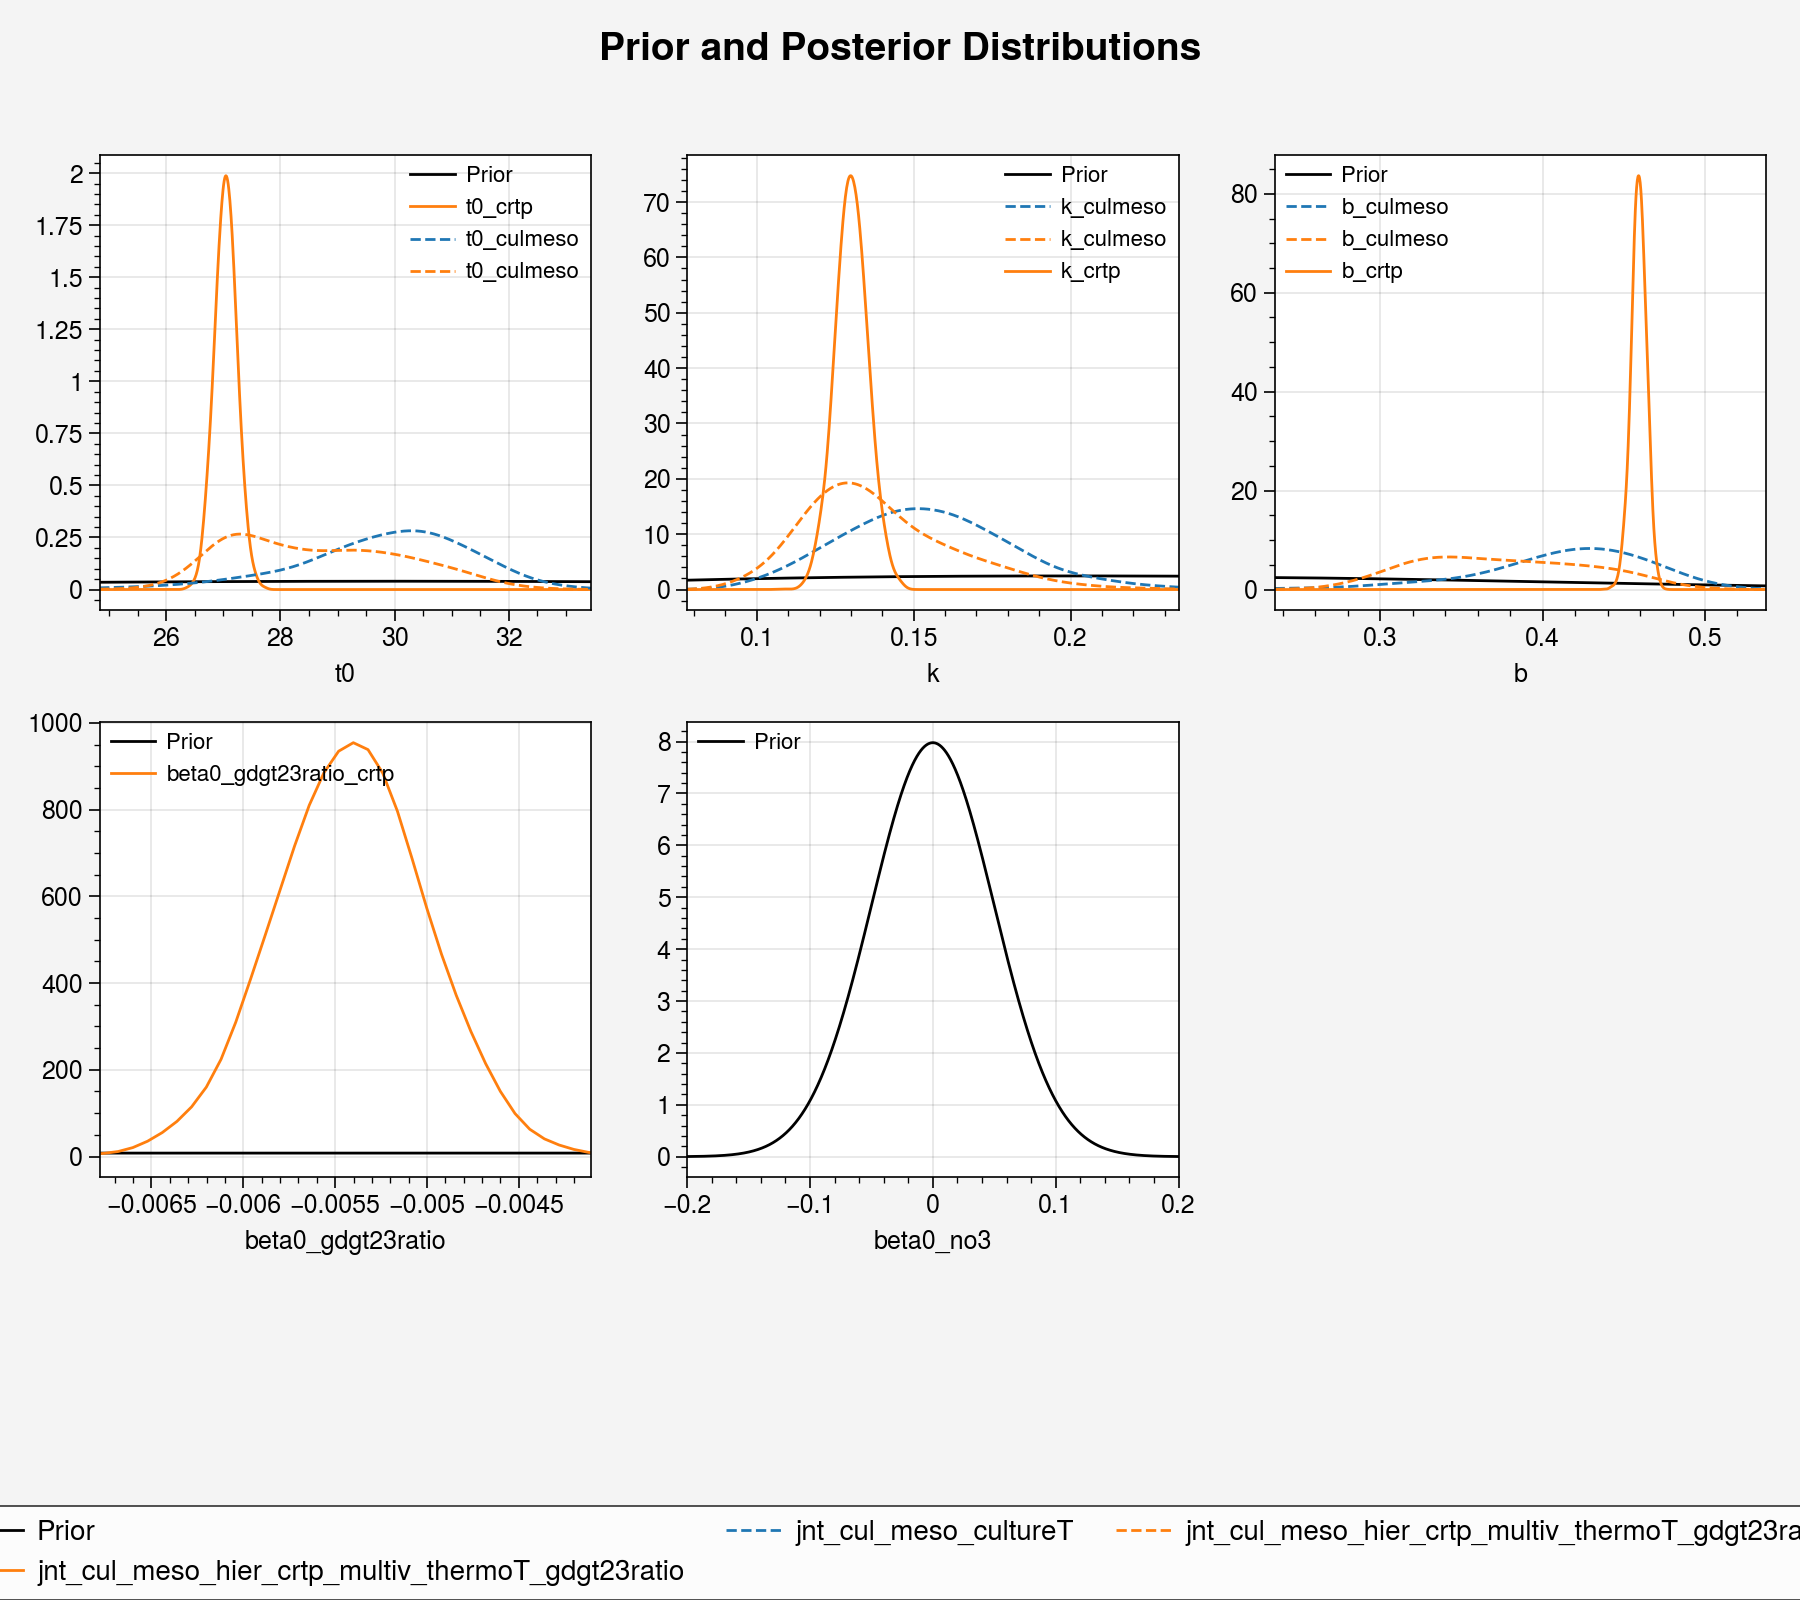

In [37]:
post_ds = culRIB.load_posterior('jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio')
priors = post_ds.attrs['priors']
dv.plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                post_ds
                                ],
                            use_linestyle_by_param=True,
                            show_histogram=False,
                            set_linewidth=1,
                            set_bottom_space=0.2,
                            set_fig_height_factor=4
                            )

In [38]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [
#     1, 1.5, 2, 2.5, 
#     2.7,
#     5, 10, 15,100
#     ]
# for no3_cutoff in no3_cutoff_values:
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(t_crtp),
#         "t_crtp": t_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                                 stan_file_name,
#                                                                                 temptype='thermoT',
#                                                                                 )
#     display(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

In [39]:
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median', 'no3_sf2tc_avg']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [
#     1, 1.5, 2, 2.5, 
#     2.7,
#     5, 10, 15, 100
#     ]
# for no3_cutoff in no3_cutoff_values:
    
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(sst_crtp),
#         "t_crtp": sst_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                                     stan_file_name,
#                                                                                     temptype='sst',
#                                                                                     )
#     display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

In [40]:
# # dropna for coretop dataset
# reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'no3_sf2tc_avg']].dropna()
# t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [
#     1, 1.5, 2, 2.5, 
#     2.7,
#     5, 10, 15,100
#     ]
# for no3_cutoff in no3_cutoff_values:
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(t_crtp),
#         "t_crtp": t_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         # "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                             stan_file_name,
#                                                                             temptype='thermoT',
#                                                                             )
#     display(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

In [41]:
# # dropna for coretop dataset
# reg_data = coretop_df[['sst', 'scaledRI_median', 'no3_sf2tc_avg']].dropna()
# sst_crtp = reg_data['sst'].astype(float).tolist()
# scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
# no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

# no3_cutoff_values = [
#     1, 1.5, 2, 2.5, 
#     2.7,
#     5, 10, 15, 100
#     ]
# for no3_cutoff in no3_cutoff_values:
    
#     ### cul + meso + coretop
#     data = {
#         "N_cul": len(culture_data_full),
#         "t_cul": t_cul,
#         "scaledRI_cul": scaledRI_cul,
#         "N_meso": len(meso_data_full),
#         "t_meso": t_meso,
#         "scaledRI_meso": scaledRI_meso,
#         "N_crtp": len(sst_crtp),
#         "t_crtp": sst_crtp,
#         "scaledRI_crtp": scaledRI_crtp,
#         # "gdgt23ratio_crtp": gdgt23ratio_crtp,
#         "no3_crtp": no3_crtp,
#         "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

#     }
#     stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
#     jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
#                                                                                 stan_file_name,
#                                                                                 temptype='sst',
#                                                                                 )
#     display(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

#     # Save posteriors
#     culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

# Posterior plots --- QC

### 1. Joint culture-mesocosm

['t0', 'k', 'b']


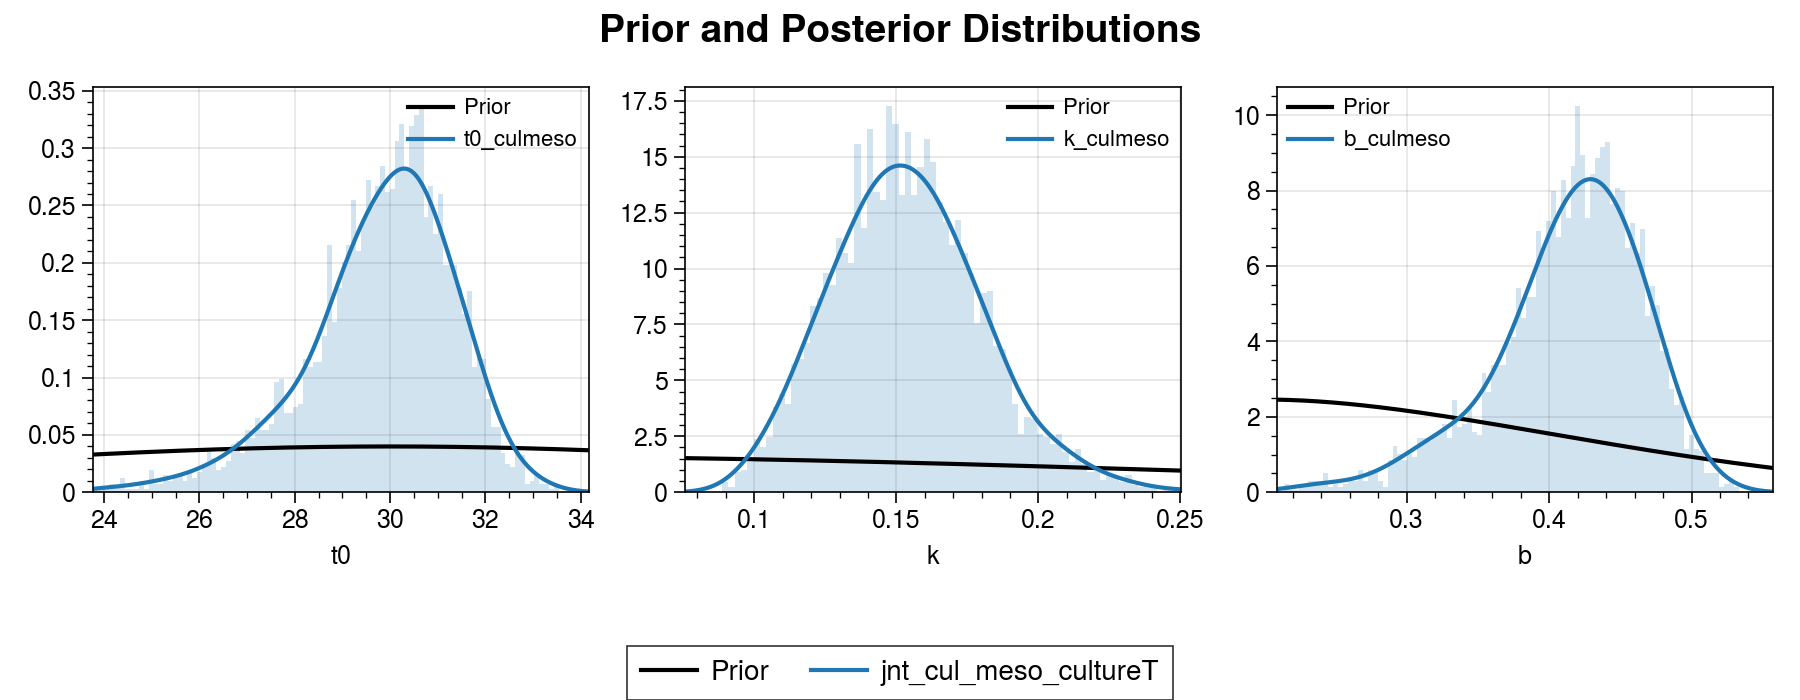

In [42]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

['t0', 'k', 'b']


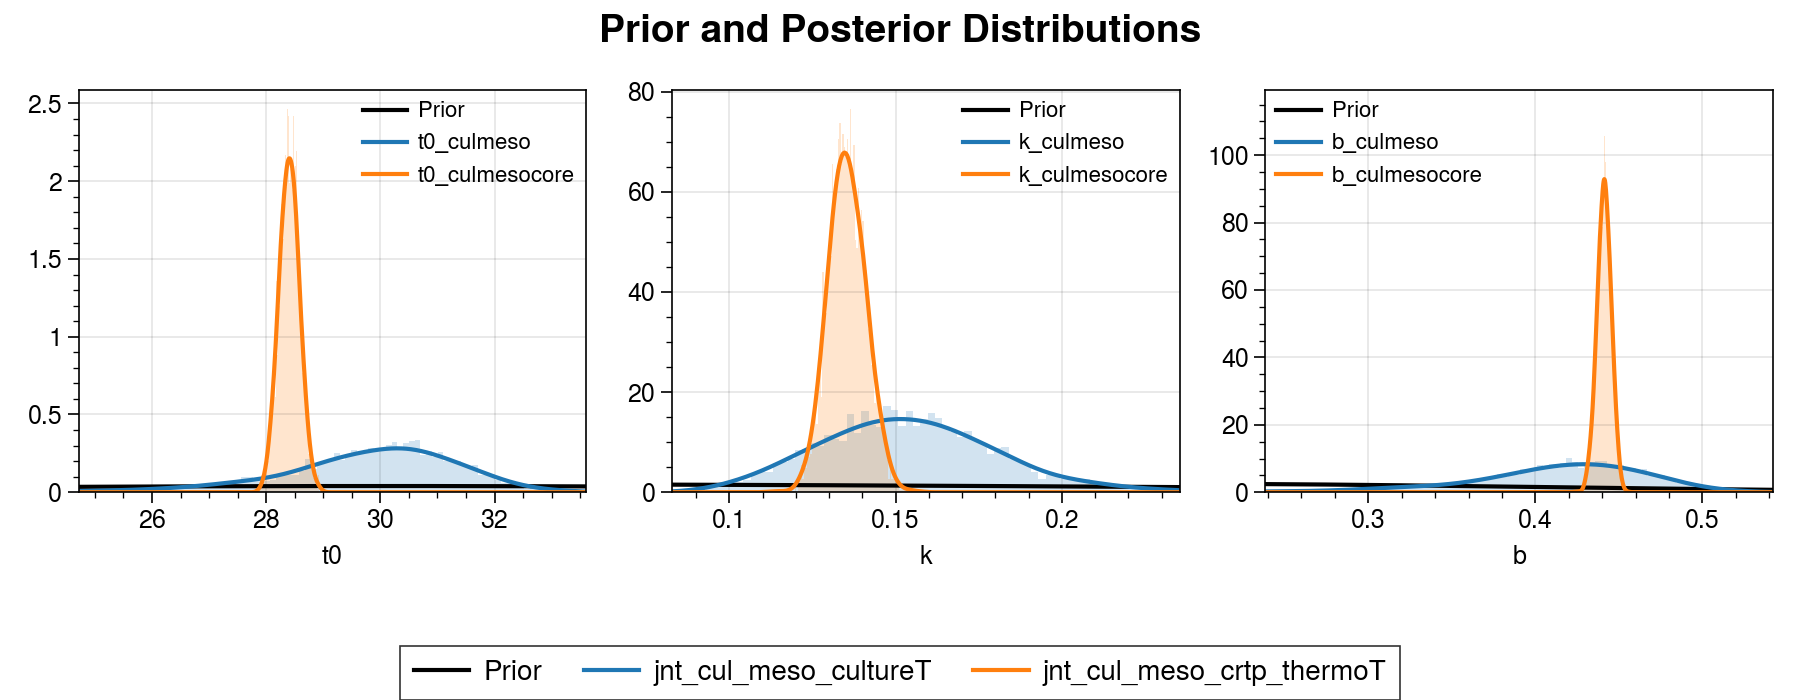

In [43]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

['t0', 'k', 'b']


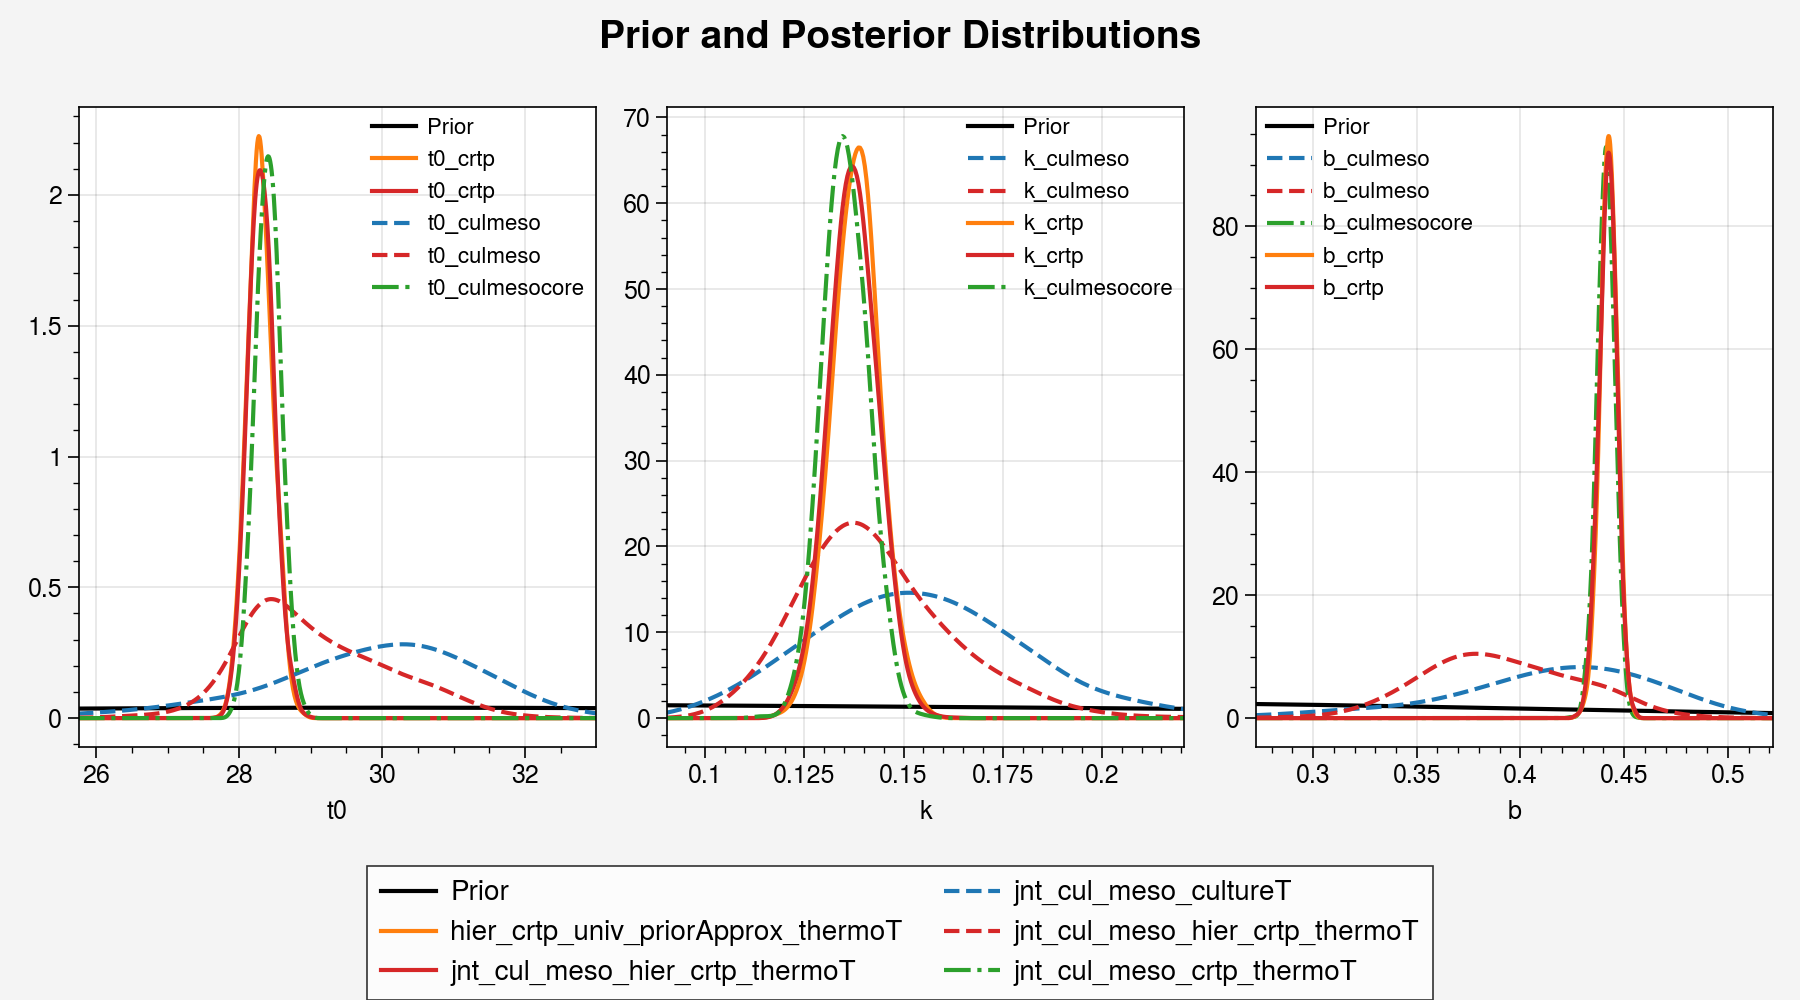

In [44]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_hier_crtp_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


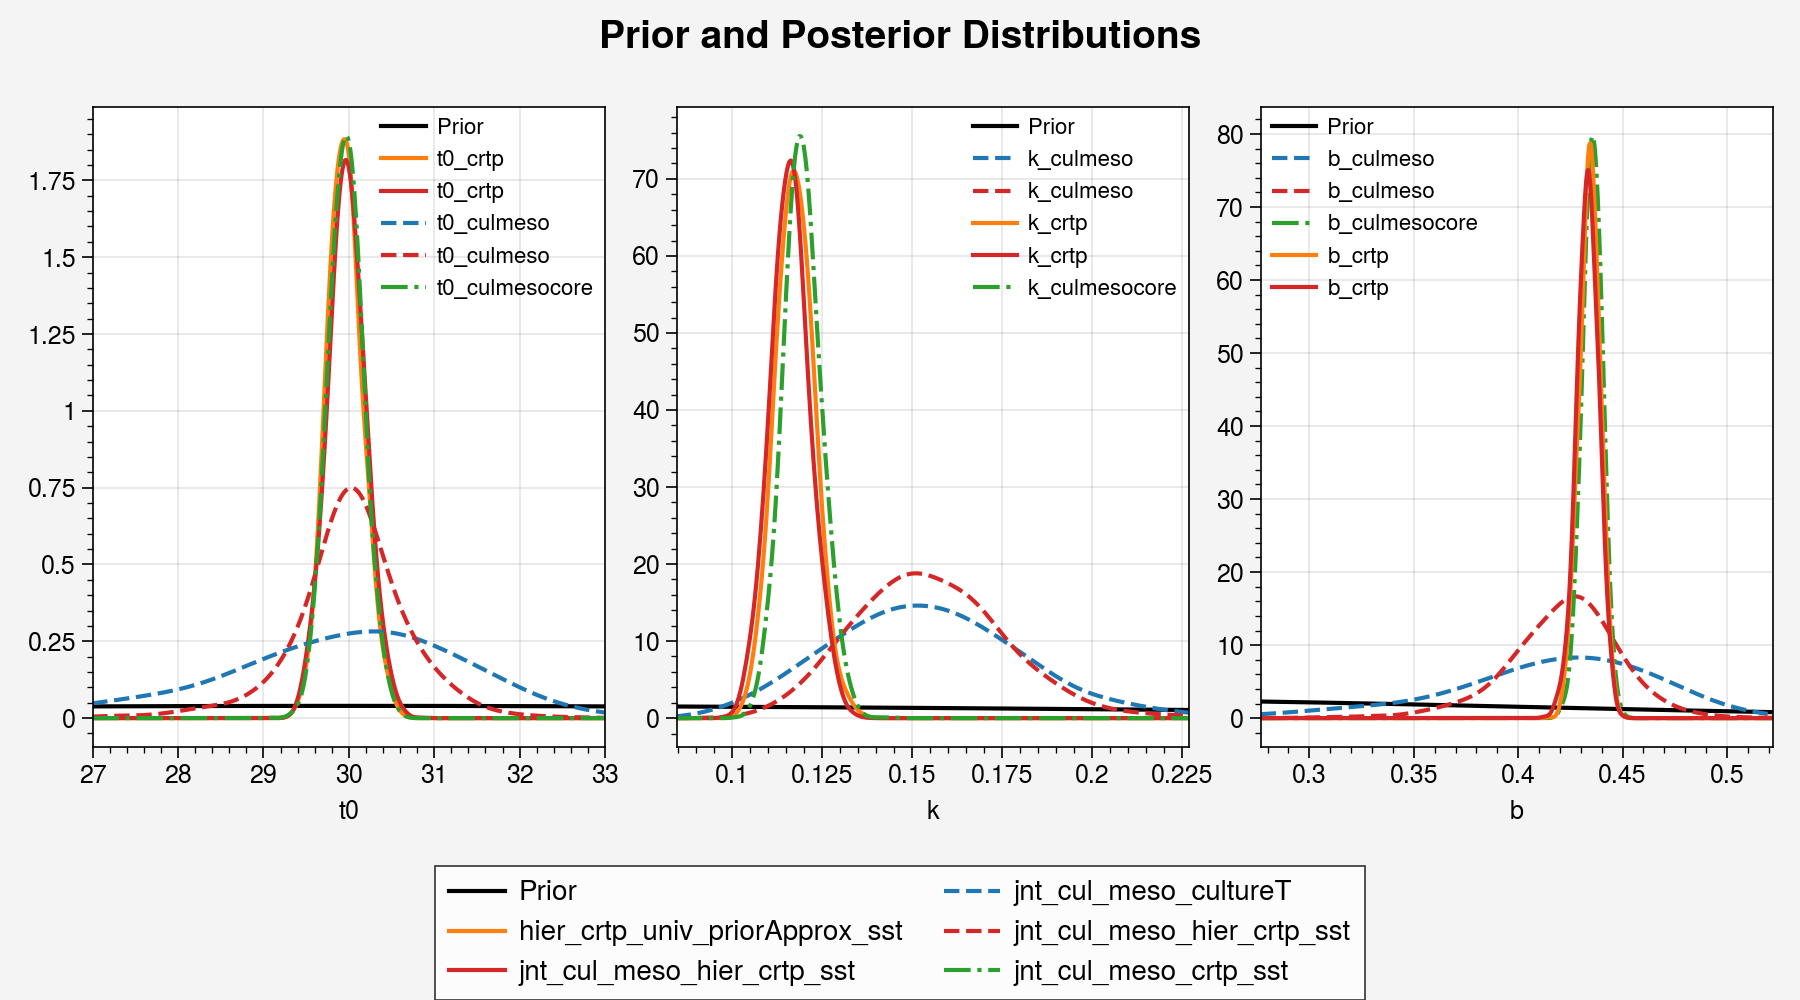

In [45]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_sst_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_sst_post_ds,
        jnt_cul_meso_hier_crtp_sst_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)
axes[0][0].set_xlim(27,33)
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


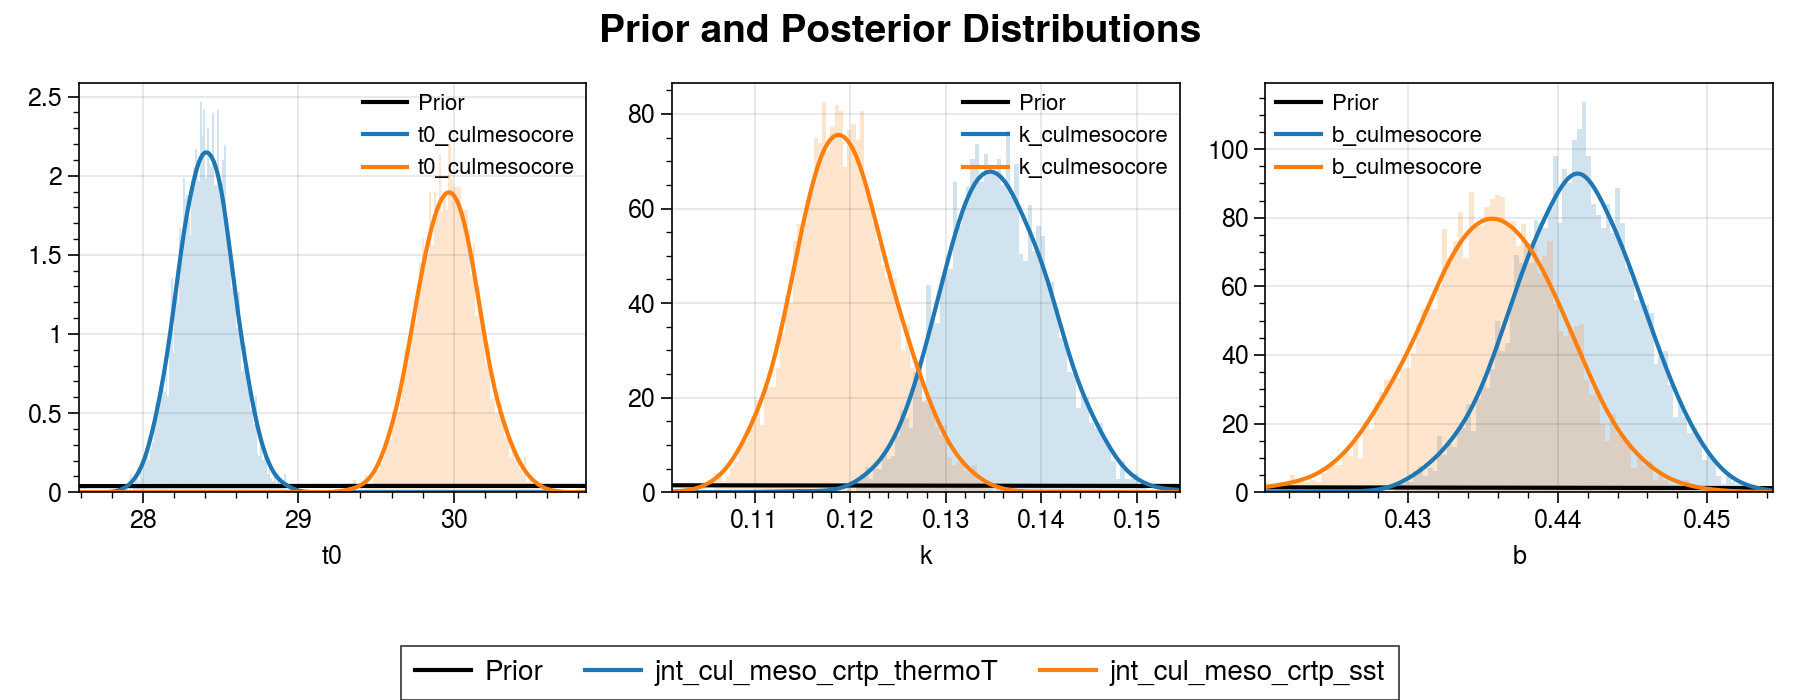

In [46]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


In [47]:
jnt_cul_meso_post_ds.attrs.get('use_gdgt23ratio',0)

0

In [48]:
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0'
culRIB.load_posterior(stan_file_name)

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.81 25.95 29.23 ... 27.82 30.97
    k_culmeso               (draw) float64 0.1631 0.098 0.1545 ... 0.1251 0.1893
    b_culmeso               (draw) float64 0.43 0.2952 0.43 ... 0.3519 0.4633
    t0_crtp                 (draw) float64 27.21 27.74 27.84 ... 27.94 27.77
    k_crtp                  (draw) float64 0.1129 0.1185 ... 0.1163 0.1297
    b_crtp                  (draw) float64 0.4657 0.4611 ... 0.4617 0.4737
    ...                      ...
    sigma_t0_culmeso        (draw) float64 5.448 1.077 0.8419 ... 0.2808 2.413
    sigma_k_culmeso         (draw) float64 0.1745 0.1281 ... 0.3113 0.08528
    sigma_b_culmeso         (draw) float64 0.07393 1.381 0.1212 ... 0.1122 0.553
    sigma_scaledRI_cul      (draw) float64 0.06907 0.08903 ... 0.08147 0.07059
    sigma_scaledRI_meso     (draw) float64 0.09373 0.09812 ... 0.07598 0.1244
    sigma_scaledRI_crtp     (draw) float64 0.05278 0.05598 ... 0.05535 0.05396
Attributes: (12/39)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-10T14:48:05.604713
    run_duration (sec):     30.83
    temptype:               thermoT
    ...                     ...
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...
    filename:               jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio...

['t0', 'k', 'b', 'beta0_gdgt23ratio', 'beta0_no3']


(25.0, 35.0)

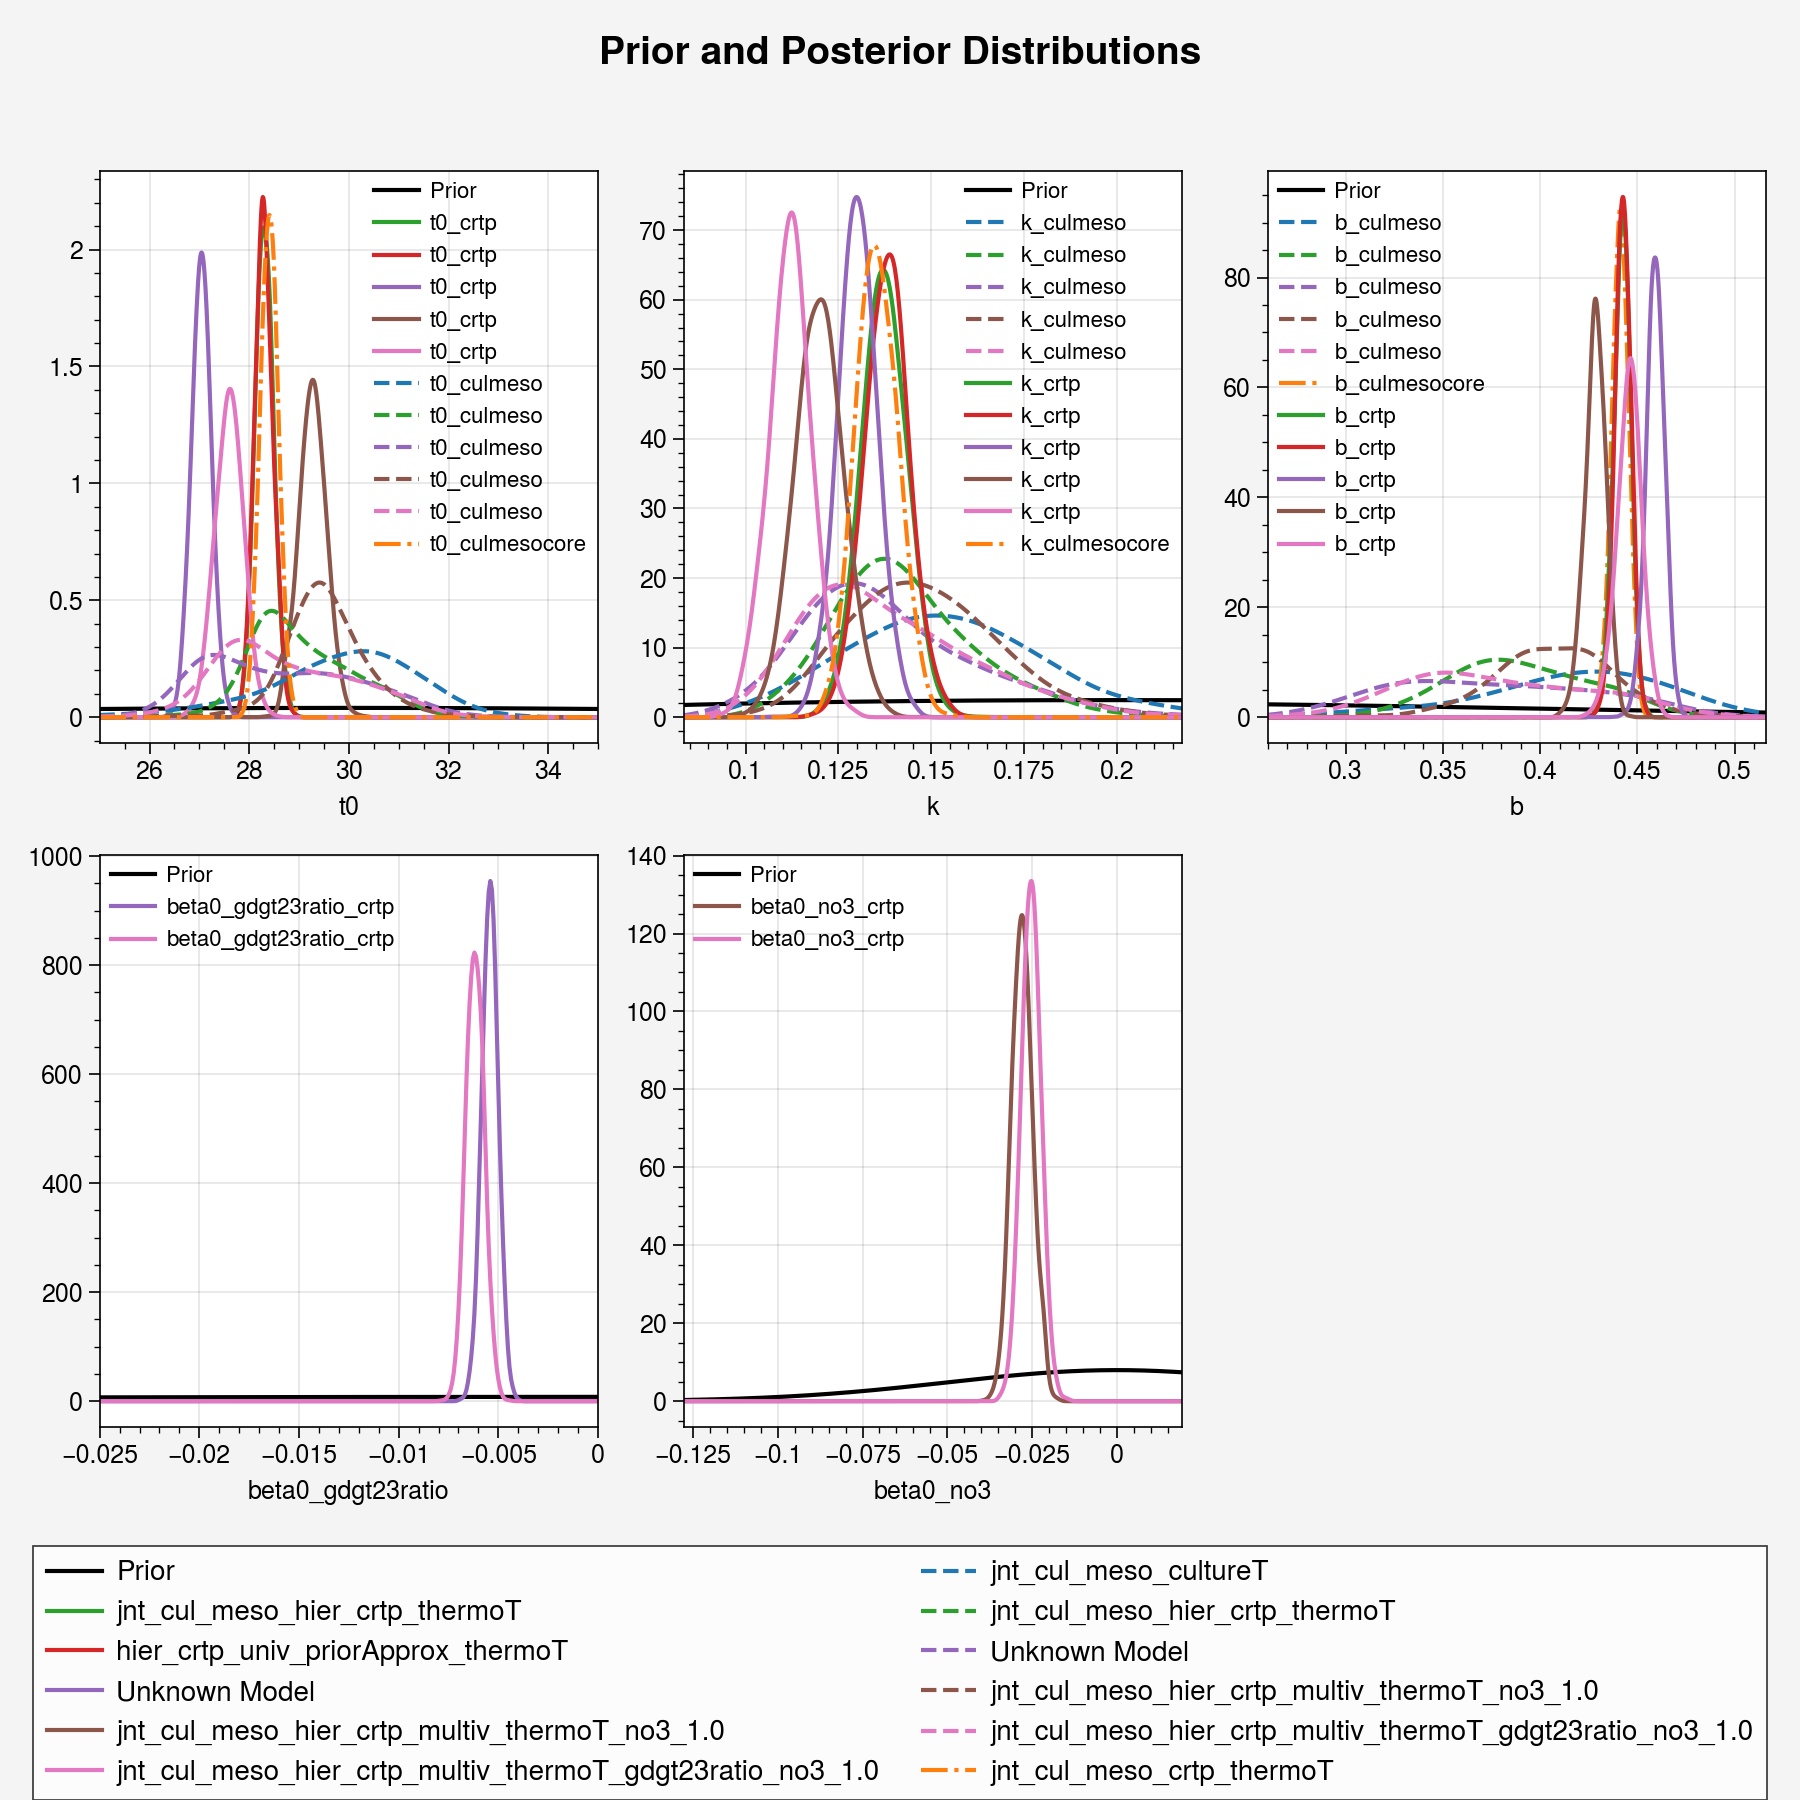

In [49]:
## load the posterior datasets
jnt_cul_meso_hier_crtp_multiv_no3_post_ds = culRIB.load_posterior('jnt_cul_meso_hier_crtp_multiv_thermoT_no3_1.0')
jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds = culRIB.load_posterior('jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.0')
priors = jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

fig, axes = dv.plot_prior_distributions(
                priors,
                posterior_datasets=[
                    jnt_cul_meso_post_ds,
                    jnt_cul_meso_crtp_post_ds,
                    jnt_cul_meso_hier_crtp_post_ds,
                    hier_crtp_univ_prior_approx_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_no3_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds,
                    ],

                # focus_on_posterior=False,
                use_linestyle_by_param=True,
                show_histogram=False,
                set_leg_max_ncol=2,
                set_fig_height_factor=4.5,
                # suffix_include=["crtp","culmesocore"]
                )

axes[1][0].set_xlim(-0.025,0)
axes[0][0].set_xlim(25,35)

<AxesSubplot:>

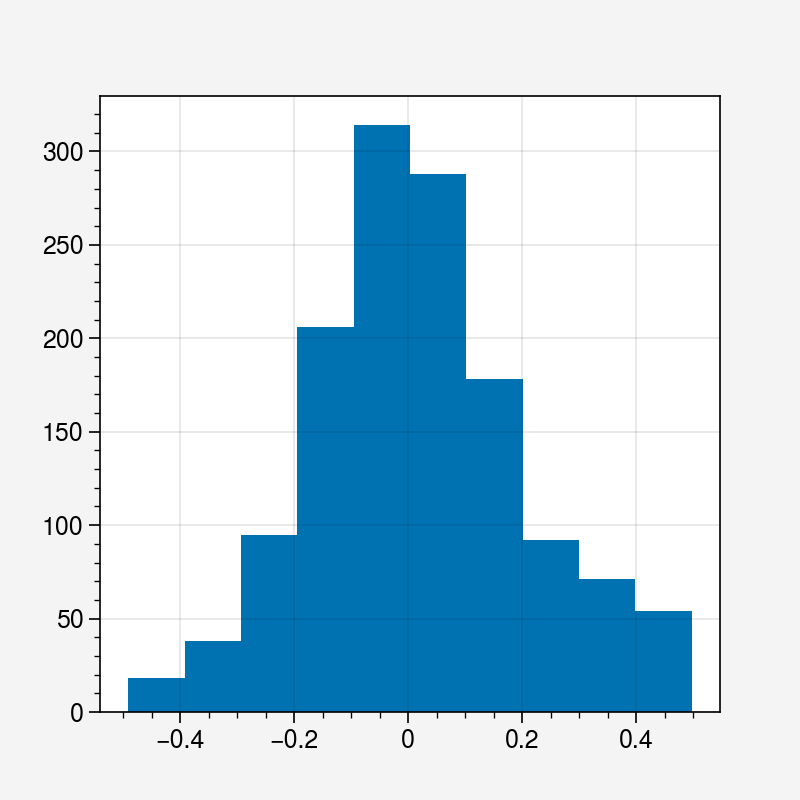

In [50]:
coretop_df['new_deltaRI'].hist()

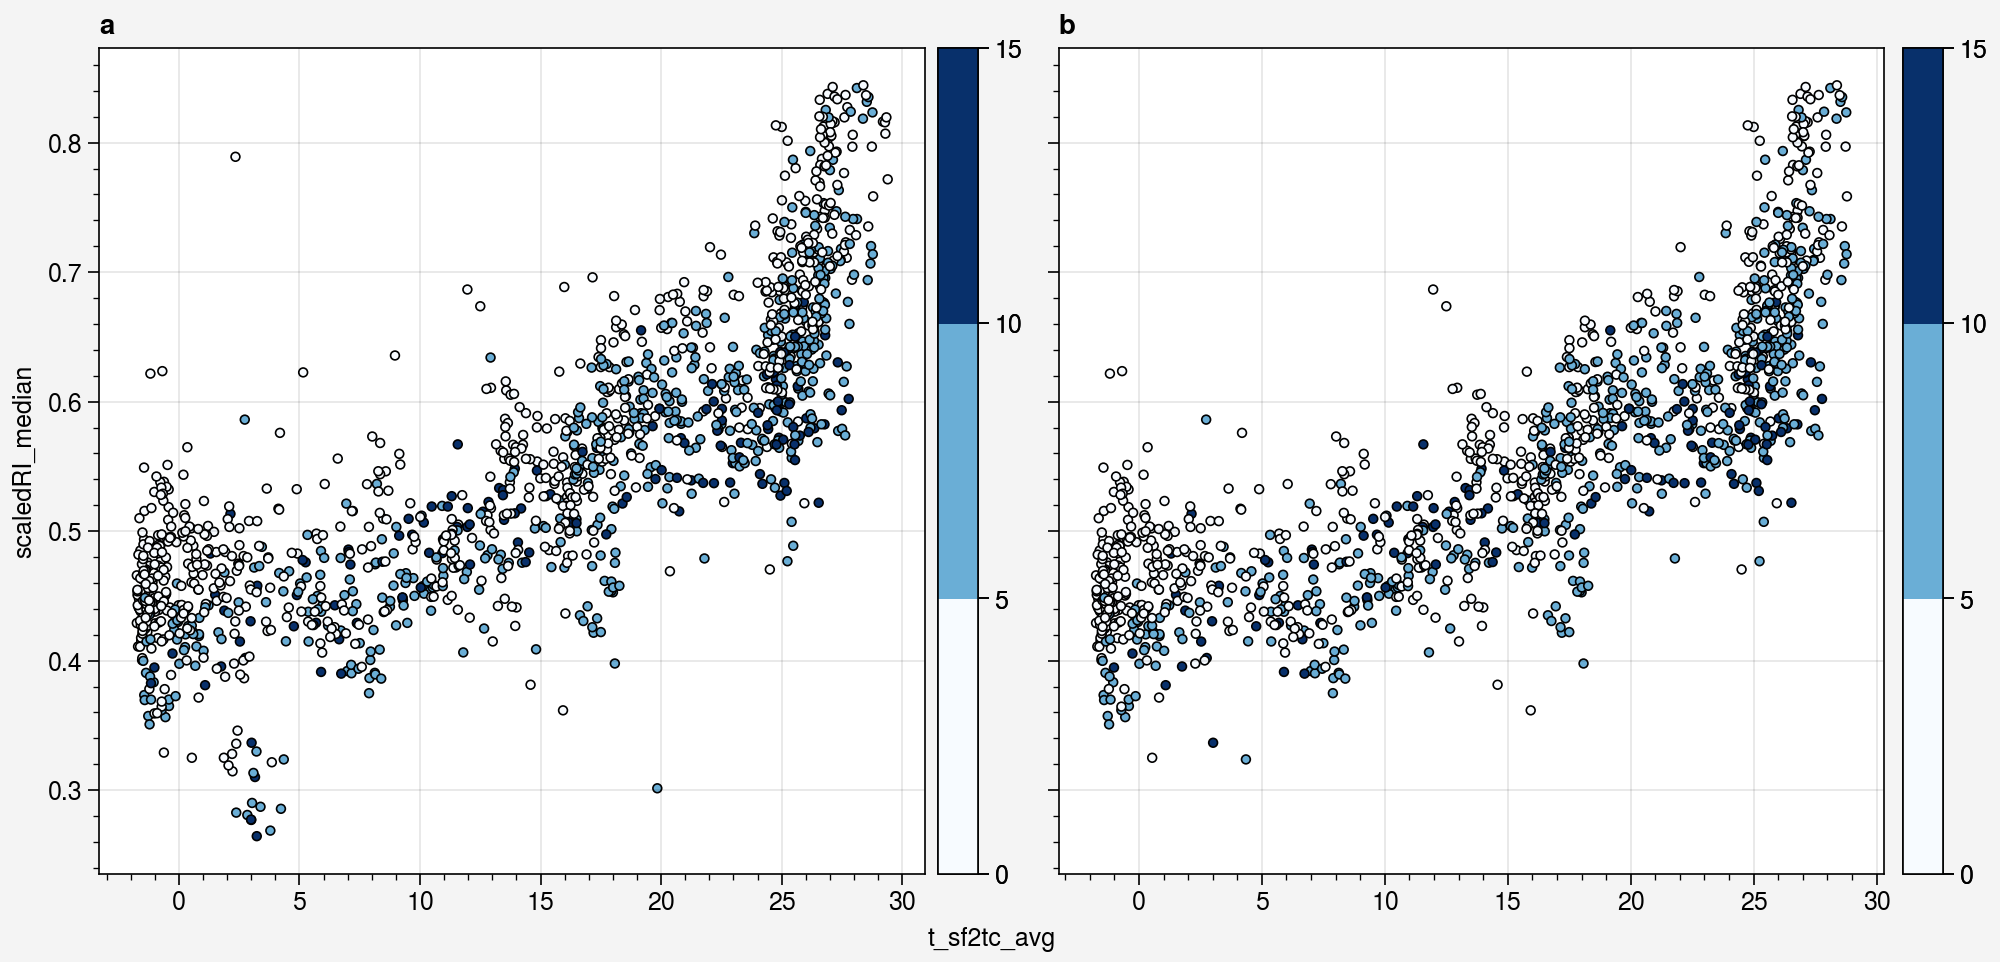

In [51]:
fig,  axs = plot.subplots(ncols=2,width=10)
plot_data = coretop_df_temp
ax = axs[0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
plot_c = plot_data['gdgt23ratio_median']
m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
ax.colorbar(m, loc='r')

plot_data = coretop_df
ax = axs[1]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
plot_c = plot_data['gdgt23ratio_median']
m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
ax.colorbar(m, loc='r')